VALENTINA ACEVEDO MESA - 1000763409

LUIS EDUARDO GRAJALES HERNANDEZ - 

JUAN JOSÉ GARCÉS ROJAS - 1007409305

# Consulta: índices del EEG adicionales a la densidad espectral de potencia para clasificación en BCI

En este proyecto se busca analizar señales EEG asociadas a condiciones de reposo, imaginación de movimiento de mano izquierda e imaginación de movimiento de mano derecha. En el dataset EEG Motor Movement/Imagery, los eventos `T0`, `T1` y `T2` permiten identificar las condiciones experimentales. Para los runs 3, 4, 7, 8, 11 y 12, `T0` corresponde a reposo, `T1` corresponde a movimiento o imaginación de movimiento de la mano izquierda y `T2` corresponde a movimiento o imaginación de movimiento de la mano derecha [1].

Aunque la densidad espectral de potencia permite estudiar cómo se distribuye la energía de la señal EEG en diferentes bandas de frecuencia, en sistemas BCI basados en imaginación motora no siempre es suficiente usar únicamente este tipo de característica. Las señales EEG son no estacionarias, variables entre sujetos y pueden tener información relevante en el dominio temporal, espacial, tiempo-frecuencia y no lineal. Por esta razón, en la literatura se han propuesto diferentes índices adicionales para mejorar la representación de la señal y apoyar la clasificación de estados en BCI [2].

A continuación, se presentan índices adicionales a la densidad espectral de potencia que pueden implementarse en Python y que pueden aportar información útil para clasificar estados de reposo, imaginación de movimiento de mano izquierda e imaginación de movimiento de mano derecha.

---

## 1. Patrones Espaciales Comunes (Common Spatial Patterns, CSP)

Los Patrones Espaciales Comunes, conocidos como CSP, son una técnica de extracción de características espaciales ampliamente utilizada en BCI con EEG, especialmente en tareas de imaginación motora. El objetivo de CSP es encontrar combinaciones espaciales de los canales EEG que maximicen la varianza de una clase y minimicen la varianza de otra. De esta manera, los canales originales se transforman en nuevos componentes que resaltan mejor las diferencias entre condiciones [3].

Este índice es útil en imaginación motora porque las tareas de mano derecha y mano izquierda generan cambios en zonas sensorimotoras del cerebro. Por ejemplo, los canales `C3`, `Cz` y `C4` suelen ser de interés porque están relacionados con la actividad motora. En trabajos clásicos de BCI se ha demostrado que los filtros espaciales en EEG multicanal permiten extraer información discriminativa entre ensayos de imaginación de movimiento de mano izquierda y derecha [3].

Además, la librería MNE-Python incluye ejemplos de decodificación de imaginación motora usando CSP, donde las señales EEG son filtradas, transformadas con CSP y luego usadas como entrada para un clasificador [4].

**Aplicación en el proyecto:**

En este proyecto, CSP puede aplicarse sobre las épocas de EEG filtradas entre 8 y 30 Hz, rango que incluye principalmente los ritmos mu y beta. Las características obtenidas pueden usarse para comparar reposo, imaginación de mano izquierda e imaginación de mano derecha, o directamente para entrenar clasificadores como SVM, XGBoost o redes neuronales.

---

## 2. Parámetros de Hjorth

Los parámetros de Hjorth son características temporales que describen propiedades de la forma y variabilidad de una señal EEG. Estos parámetros fueron propuestos para el análisis de señales EEG en el dominio del tiempo y se componen principalmente de actividad, movilidad y complejidad [5].

### Actividad

La actividad mide la varianza de la señal. Se relaciona con la amplitud o energía general de la señal en el tiempo [5].

$$
Actividad = var(x(t))
$$

### Movilidad

La movilidad mide qué tan rápido cambia la señal en el tiempo. Se calcula a partir de la relación entre la varianza de la derivada de la señal y la varianza de la señal original [5].

$$
Movilidad = \sqrt{\frac{var(\frac{dx(t)}{dt})}{var(x(t))}}
$$

### Complejidad

La complejidad mide qué tan variable o irregular es la forma de la señal. Se calcula comparando la movilidad de la derivada con la movilidad de la señal original [5].

$$
Complejidad = \frac{Movilidad(\frac{dx(t)}{dt})}{Movilidad(x(t))}
$$

Estos parámetros son útiles porque permiten describir la señal EEG directamente en el dominio temporal, sin depender únicamente del análisis frecuencial. Además, tienen bajo costo computacional y pueden calcularse fácilmente para cada canal y cada época. En estudios de procesamiento EEG para imaginación motora se ha señalado que el análisis de estas señales requiere considerar tanto características temporales como frecuenciales debido a su comportamiento no estacionario [6].

**Aplicación en el proyecto:**

Para cada segmento EEG se pueden calcular los parámetros de Hjorth en los canales `C3`, `Cz` y `C4`. Por ejemplo:

- Actividad en C3.
- Movilidad en C3.
- Complejidad en C3.
- Actividad en C4.
- Movilidad en C4.
- Complejidad en C4.

Estos valores pueden almacenarse en un dataframe junto con el sujeto, el run y la condición evaluada.

---

## 3. Entropía de la señal EEG

La entropía es una medida que permite cuantificar el grado de irregularidad, desorden o complejidad de una señal. En EEG, puede ayudar a identificar diferencias entre condiciones que no son evidentes únicamente mediante la densidad espectral de potencia.

En paradigmas BCI de imaginación motora se han usado diferentes tipos de entropía, como entropía de Shannon, entropía muestral, entropía aproximada, entropía difusa y entropía de permutación. Una revisión enfocada en entropía aplicada a MI-BCI reporta que estas medidas son usadas como características para describir la complejidad de la señal EEG y apoyar tareas de clasificación [7].

Una señal más regular o más predecible tiende a presentar menor entropía, mientras que una señal más irregular tiende a presentar mayor entropía. Esto puede ser útil para comparar si las condiciones de reposo, mano izquierda imaginada y mano derecha imaginada presentan diferencias en la complejidad de la actividad cerebral.

**Aplicación en el proyecto:**

En este proyecto se puede implementar, por ejemplo, la entropía de permutación o la entropía muestral para cada época y cada canal. Estas características pueden complementar la información obtenida mediante la densidad espectral de potencia y los parámetros temporales.

---

## 4. Características tiempo-frecuencia mediante Wavelet

La transformada wavelet permite analizar cómo cambia el contenido frecuencial de una señal a lo largo del tiempo. Esto es importante en EEG porque las señales cerebrales no son completamente estacionarias. A diferencia de la densidad espectral de potencia tradicional, que resume la información frecuencial de un segmento completo, la transformada wavelet permite observar variaciones temporales dentro de la señal [8].

En clasificación de imaginación motora se han usado características basadas en wavelet, como energía por subbanda, entropía wavelet y características obtenidas mediante wavelet packet. Estos métodos permiten representar la señal EEG en el dominio tiempo-frecuencia y pueden aportar información complementaria para la clasificación [8], [9].

**Aplicación en el proyecto:**

En este proyecto se puede aplicar una transformada wavelet discreta a cada época EEG y calcular características como:

- Energía wavelet en C3.
- Entropía wavelet en C3.
- Energía wavelet en C4.
- Entropía wavelet en C4.
- Energía relativa por subbanda.

Estas características pueden compararse entre reposo, imaginación de mano izquierda e imaginación de mano derecha.

---

## Índices seleccionados para implementar

Para este proyecto se propone implementar los siguientes índices adicionales a la densidad espectral de potencia:

| Índice | Tipo de característica | Utilidad en BCI |
|---|---|---|
| CSP | Espacial | Resalta diferencias entre condiciones usando varios canales EEG |
| Parámetros de Hjorth | Temporal | Describe amplitud, variabilidad y complejidad de la señal |
| Entropía | No lineal | Mide irregularidad o complejidad de la señal EEG |
| Wavelet | Tiempo-frecuencia | Captura cambios de frecuencia a lo largo del tiempo |

Aunque todos los índices anteriores pueden aportar información útil, los tres más recomendados para iniciar el análisis son CSP, parámetros de Hjorth y entropía. Estos índices son relativamente directos de implementar en Python, complementan el análisis basado en potencia espectral y pueden generar características útiles para los modelos de clasificación.

---

## Conclusión

Con base en la revisión realizada, se concluye que para mejorar la clasificación de estados en BCI no es suficiente analizar únicamente la densidad espectral de potencia. En tareas de imaginación motora, las diferencias entre condiciones pueden observarse también en la distribución espacial de la actividad EEG, en la forma temporal de la señal, en su complejidad no lineal y en su comportamiento tiempo-frecuencia [2], [3], [7].

Por esta razón, se seleccionan como índices adicionales los Patrones Espaciales Comunes, los parámetros de Hjorth, la entropía y las características wavelet. Estos índices pueden calcularse sobre las épocas correspondientes a reposo, imaginación de mano izquierda e imaginación de mano derecha, y posteriormente utilizarse como entradas para modelos de clasificación.

---

## Referencias

[1] PhysioNet. *EEG Motor Movement/Imagery Dataset*. Disponible en:  
https://archive.physionet.org/pn4/eegmmidb/

[2] Degirmenci, M. et al. *Statistically significant features improve binary and multiple Motor Imagery task predictions from EEGs*. Frontiers in Human Neuroscience. Disponible en:  
https://www.frontiersin.org/journals/human-neuroscience/articles/10.3389/fnhum.2023.1223307/full

[3] Ramoser, H., Müller-Gerking, J., & Pfurtscheller, G. (2000). *Optimal spatial filtering of single trial EEG during imagined hand movement*. IEEE Transactions on Rehabilitation Engineering. Disponible en:  
https://pubmed.ncbi.nlm.nih.gov/11204034/

[4] MNE-Python. *Motor imagery decoding from EEG data using the Common Spatial Pattern (CSP)*. Disponible en:  
https://mne.tools/stable/auto_examples/decoding/decoding_csp_eeg.html

[5] Hjorth, B. (1970). *EEG analysis based on time domain properties*. Electroencephalography and Clinical Neurophysiology.

[6] Oh, S. H., Lee, Y. R., & Kim, H. N. *A Novel EEG Feature Extraction Method using Hjorth Parameter*. Disponible en:  
https://cspl.pusan.ac.kr/sites/cspl/download/internation_c/ICAEE2014_02_OSH.pdf

[7] *The Application of Entropy in Motor Imagery Paradigms of Brain–Computer Interfaces*. Disponible en:  
https://pmc.ncbi.nlm.nih.gov/articles/PMC11853529/

[8] *Motor imagery classification method based on relative wavelet packet energy and cloud model*. Disponible en:  
https://pmc.ncbi.nlm.nih.gov/articles/PMC9936148/

[9] *Feature Extraction of Motor Imagery EEG via Discrete Wavelet Transform*. Disponible en:  
https://www.mdpi.com/2079-9292/12/10/2207

# Instalación e importación de librerías

In [ ]:
pip -q install mne tqdm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import os
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mne
from tqdm import tqdm

from scipy.signal import welch, coherence
from math import factorial

# Rutas para la extracción de la información y extracción 

In [ ]:
ZIP_PATH = Path("eeg-motor-movementimagery-dataset-1.0.0.zip")
DATA_DIR = Path("data_eeg")
RESULTS_DIR = Path("resultados")

DATA_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

print("Ruta del ZIP:", ZIP_PATH.resolve())
print("Carpeta de datos:", DATA_DIR.resolve())
print("Carpeta de resultados:", RESULTS_DIR.resolve())

if not ZIP_PATH.exists():
    raise FileNotFoundError(
        "No se encontró el archivo ZIP. "
        "Verifica que 'eeg-motor-movementimagery-dataset-1.0.0.zip' esté en la misma carpeta del notebook."
    )
else:
    print("ZIP encontrado correctamente.")

Ruta del ZIP: C:\Users\User\Documents\UdeA\BIOSENALES\eeg-motor-movementimagery-dataset-1.0.0.zip
Carpeta de datos: C:\Users\User\Documents\UdeA\BIOSENALES\data_eeg
Carpeta de resultados: C:\Users\User\Documents\UdeA\BIOSENALES\resultados
ZIP encontrado correctamente.


In [ ]:
edf_existentes = list(DATA_DIR.rglob("*.edf"))

if len(edf_existentes) == 0:
    print("Extrayendo archivos del ZIP...")

    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(DATA_DIR)

    print("Extracción finalizada.")
else:
    print("Ya hay archivos EDF extraídos. No se vuelve a extraer.")

Ya hay archivos EDF extraídos. No se vuelve a extraer.


### Búsqueda de los archivos EDF del estudio

In [ ]:
edf_files = sorted(DATA_DIR.rglob("*.edf"))

print("Cantidad total de archivos EDF encontrados:", len(edf_files))

for archivo in edf_files[:10]:
    print(archivo)

Cantidad total de archivos EDF encontrados: 1526
data_eeg\files\S001\S001R01.edf
data_eeg\files\S001\S001R02.edf
data_eeg\files\S001\S001R03.edf
data_eeg\files\S001\S001R04.edf
data_eeg\files\S001\S001R05.edf
data_eeg\files\S001\S001R06.edf
data_eeg\files\S001\S001R07.edf
data_eeg\files\S001\S001R08.edf
data_eeg\files\S001\S001R09.edf
data_eeg\files\S001\S001R10.edf


### Runs de interés
Se seleccionan los runs correspondientes a imaginería motora de la mano izquierda y mano derecha que corresponden al run 4, 8 y 12 de todos los sujetos de prueba

In [ ]:
# Para imaginación motora mano izquierda y mano derecha:
runs_imaginacion = ["R04", "R08", "R12"]

# Para movimiento real mano izquierda y mano derecha, si también lo necesitan:
runs_movimiento_real = ["R03", "R07", "R11"]

# Por ahora empecemos con imaginación motora
runs_interes = runs_imaginacion

edf_interes = [
    archivo for archivo in edf_files
    if any(run in archivo.name for run in runs_interes)
]

print("Cantidad de archivos de interés:", len(edf_interes))

for archivo in edf_interes[:20]:
    print(archivo.name)

Cantidad de archivos de interés: 327
S001R04.edf
S001R08.edf
S001R12.edf
S002R04.edf
S002R08.edf
S002R12.edf
S003R04.edf
S003R08.edf
S003R12.edf
S004R04.edf
S004R08.edf
S004R12.edf
S005R04.edf
S005R08.edf
S005R12.edf
S006R04.edf
S006R08.edf
S006R12.edf
S007R04.edf
S007R08.edf


# Selección de un archivo de prueba

In [ ]:
archivo_prueba = None

for archivo in edf_interes:
    if "S001R04" in archivo.name:
        archivo_prueba = archivo
        break

print("Archivo seleccionado:")
print(archivo_prueba)

if archivo_prueba is None:
    raise FileNotFoundError("No se encontró S001R04.edf dentro de los archivos extraídos.")

Archivo seleccionado:
data_eeg\files\S001\S001R04.edf


Función para limpiar los nombres de los canales y por ende evitar caracteres no necesarios como los puntos después del nombre del canal

In [ ]:
def limpiar_nombres_canales(raw):
    """
    Limpia los nombres de canales del dataset.
    Ejemplo:
    'C3..' -> 'C3'
    'Cz..' -> 'Cz'
    'C4..' -> 'C4'
    """
    nuevos_nombres = {}

    for canal in raw.ch_names:
        canal_limpio = canal.replace(".", "").replace(" ", "")
        nuevos_nombres[canal] = canal_limpio

    raw.rename_channels(nuevos_nombres)
    return raw

#-------------------------------------------------------------------------------------

raw = mne.io.read_raw_edf(
    archivo_prueba,
    preload=True,
    verbose=False
)

raw = limpiar_nombres_canales(raw)

print(raw)
print("Frecuencia de muestreo:", raw.info["sfreq"], "Hz")
print("Número de canales:", len(raw.ch_names))
print("Duración:", raw.times[-1], "segundos")

print("\nPrimeros canales:")
print(raw.ch_names[:20])

<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>
Frecuencia de muestreo: 160.0 Hz
Número de canales: 64
Duración: 124.99375 segundos

Primeros canales:
['Fc5', 'Fc3', 'Fc1', 'Fcz', 'Fc2', 'Fc4', 'Fc6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'Cp5', 'Cp3', 'Cp1', 'Cpz', 'Cp2', 'Cp4']


### Lectura de las anotaciones del archivo según los eventos

En cada run de la señal se va a encontrar 3 tipos de eventos para la imaginería motora. 

- El reposo se identifica con la etiqueta: T0

- Cuando se le pide al usuario imaginar el movimiento de la mano izquierda al ver el estímulo, se clasifica con la etiqueta: T1

- Cuando se pide que se imagine el movimiento de la mano derecha, se verá la anotación: T2

In [ ]:
print(raw.annotations)

for onset, duration, description in zip(
    raw.annotations.onset,
    raw.annotations.duration,
    raw.annotations.description
):
    print(f"Inicio: {onset:.2f} s | Duración: {duration:.2f} s | Evento: {description}")

<Annotations | 30 segments: T0 (15), T1 (8), T2 (7)>
Inicio: 0.00 s | Duración: 4.20 s | Evento: T0
Inicio: 4.20 s | Duración: 4.10 s | Evento: T2
Inicio: 8.30 s | Duración: 4.20 s | Evento: T0
Inicio: 12.50 s | Duración: 4.10 s | Evento: T1
Inicio: 16.60 s | Duración: 4.20 s | Evento: T0
Inicio: 20.80 s | Duración: 4.10 s | Evento: T1
Inicio: 24.90 s | Duración: 4.20 s | Evento: T0
Inicio: 29.10 s | Duración: 4.10 s | Evento: T2
Inicio: 33.20 s | Duración: 4.20 s | Evento: T0
Inicio: 37.40 s | Duración: 4.10 s | Evento: T2
Inicio: 41.50 s | Duración: 4.20 s | Evento: T0
Inicio: 45.70 s | Duración: 4.10 s | Evento: T1
Inicio: 49.80 s | Duración: 4.20 s | Evento: T0
Inicio: 54.00 s | Duración: 4.10 s | Evento: T2
Inicio: 58.10 s | Duración: 4.20 s | Evento: T0
Inicio: 62.30 s | Duración: 4.10 s | Evento: T1
Inicio: 66.40 s | Duración: 4.20 s | Evento: T0
Inicio: 70.60 s | Duración: 4.10 s | Evento: T2
Inicio: 74.70 s | Duración: 4.20 s | Evento: T0
Inicio: 78.90 s | Duración: 4.10 s | E

### Selección de los canales de interés 
Para una señal de EEG que se asocia con el movimiento, los canales más representativos para el anális resultan ser aquellos que se ubican sobre la carteza motora primaria, la cual es la zona del cerebro encargada de la planificación, control y ejecución del movimiento voluntario y que incluso cuando no hay movimiento real sino imaginado, esta zona también genera señales eléctricas significativas. 

El cerebro funciona de manera opuesta por la decusación de las vías nerviosas, es decir, el hemisferio izquierdo controla el movimiento de la parte derecha del cuerpo y viceversa. 

El canal C3 permite reconocer las señales que se producen con la imaginación de la mano derecha y el canal C4 reconoce el movimiento de la mano izquierda. Por otro lado, el canal Cz ubicado en el centro de la corteza sirve como punto de referencia central ayudando a comparar la actividad lateralizada de los 2 canales C3 y C4. 

In [ ]:
canales_interes = ["C3", "Cz", "C4"]

canales_disponibles = [
    canal for canal in canales_interes
    if canal in raw.ch_names
]

print("Canales disponibles:", canales_disponibles)

raw_canales = raw.copy().pick(canales_disponibles)

print(raw_canales)
print(raw_canales.ch_names)

Canales disponibles: ['C3', 'Cz', 'C4']
<RawEDF | S001R04.edf, 3 x 20000 (125.0 s), ~476 KiB, data loaded>
['C3', 'Cz', 'C4']


### Comparación de la señal cruda con una señal filtrada

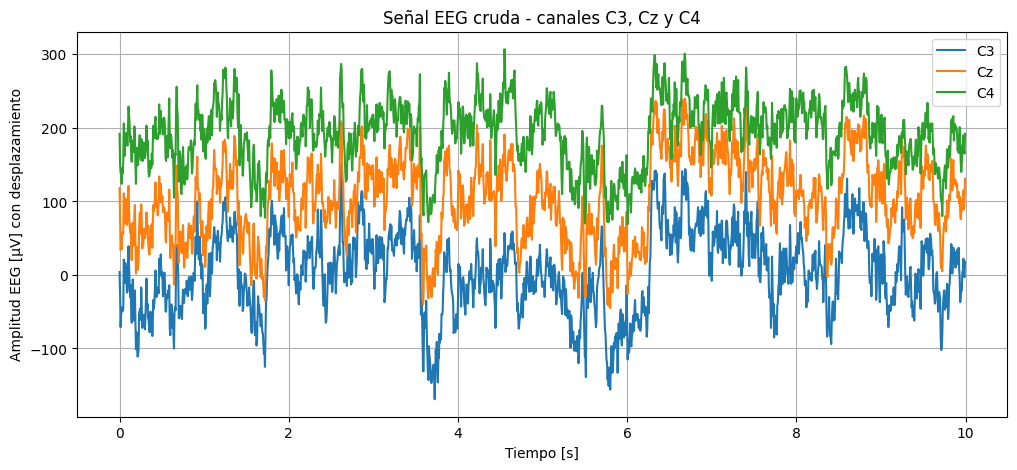

In [ ]:
duracion_segundos = 10
sfreq = raw_canales.info["sfreq"]
n_muestras = int(duracion_segundos * sfreq)

data, times = raw_canales[:, :n_muestras]

data_uv = data * 1e6        # Pasamos de voltios a microvoltios para visualizar mejor

plt.figure(figsize=(12, 5))

offset = 100

for i, canal in enumerate(raw_canales.ch_names):
    plt.plot(times, data_uv[i] + i * offset, label=canal)

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud EEG [µV] con desplazamiento")
plt.title("Señal EEG cruda - canales C3, Cz y C4")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
raw_para_filtrar = raw_canales.copy() # Se realiza una copia para aplicar los filtros sin modificar el raw original

print("Señal lista para aplicar filtros:")
print(raw_para_filtrar)

Señal lista para aplicar filtros:
<RawEDF | S001R04.edf, 3 x 20000 (125.0 s), ~476 KiB, data loaded>


### Filtro pasabanda que conserve las frecuencias de 8-30 Hz
correspondientes a recuencias mu (8-12Hz) y beta (12-30Hz) que identifican cuando hay una desincronización (ERD) o Resincronización (ERS) respectivamente que identifican cuando se presenta una intensión dde movimiento con la disminución de la amplitud de las ondas para procesar la información en el área correspondiente. Por otro lado, cuando se termina de imaginar el movimiento, se observa un aumento súbito de la potencia, especialmente en la banda beta.

In [ ]:
raw_filtrado = raw_para_filtrar.copy().filter(
    l_freq=8,
    h_freq=30,
    fir_design="firwin",
    verbose=False
)

print(raw_filtrado)

<RawEDF | S001R04.edf, 3 x 20000 (125.0 s), ~476 KiB, data loaded>


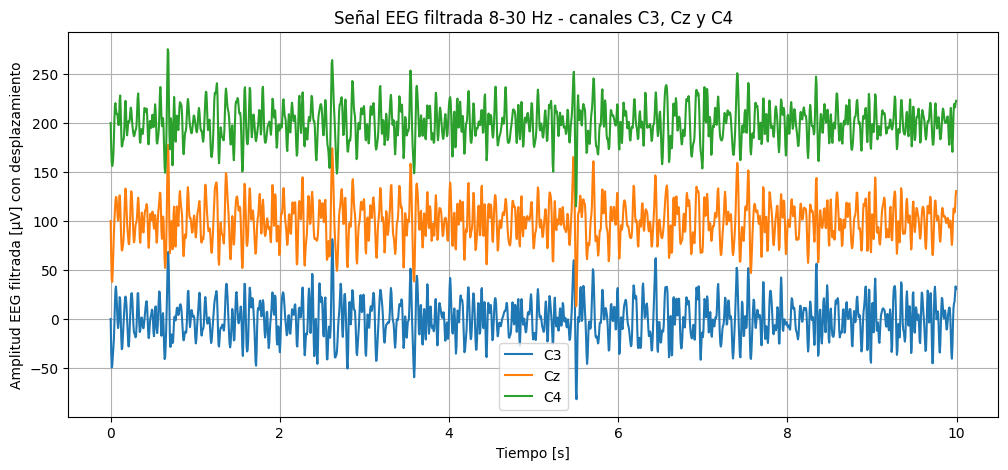

In [ ]:
# Visualizar señal filtrada

data_filt, times = raw_filtrado[:, :n_muestras]
data_filt_uv = data_filt * 1e6

plt.figure(figsize=(12, 5))

for i, canal in enumerate(raw_filtrado.ch_names):
    plt.plot(times, data_filt_uv[i] + i * offset, label=canal)

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud EEG filtrada [µV] con desplazamiento")
plt.title("Señal EEG filtrada 8-30 Hz - canales C3, Cz y C4")
plt.legend()
plt.grid(True)
plt.show()

Comparación de la señal filtrada en el canal C3

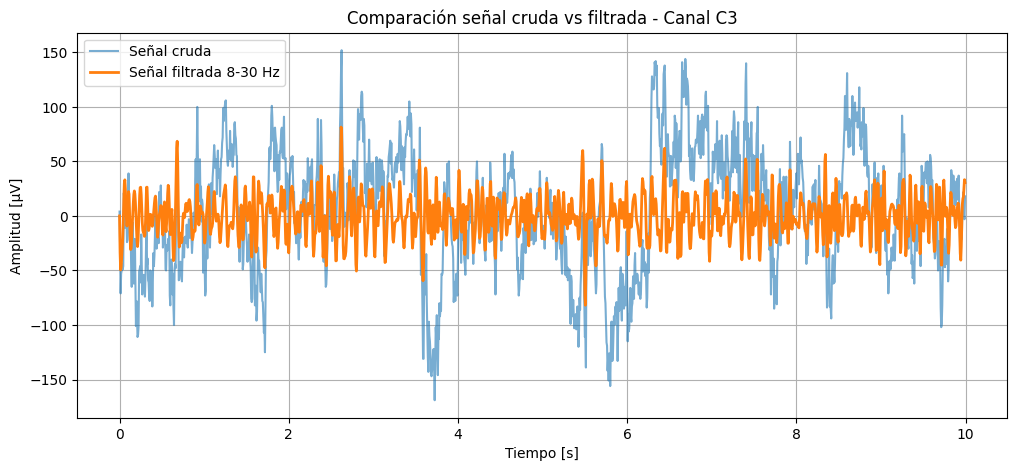

In [ ]:
canal = "C3"
duracion_segundos = 10

sfreq = raw_canales.info["sfreq"]
n_muestras = int(duracion_segundos * sfreq)

data_cruda, times = raw_canales.copy().pick([canal])[:, :n_muestras]
data_filtrada, _ = raw_filtrado.copy().pick([canal])[:, :n_muestras]

plt.figure(figsize=(12, 5))

plt.plot(times, data_cruda[0] * 1e6, label="Señal cruda", alpha=0.6)
plt.plot(times, data_filtrada[0] * 1e6, label="Señal filtrada 8-30 Hz", linewidth=2)

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [µV]")
plt.title("Comparación señal cruda vs filtrada - Canal C3")
plt.legend()
plt.grid(True)
plt.show()

### Conversión de las anotaciones en eventos a nombres que permitan la clasificación directa

In [ ]:
events, event_id_original = mne.events_from_annotations(
    raw_filtrado,
    verbose=False
)

print("Diccionario original de eventos:")
print(event_id_original)

print("\nPrimeros eventos:")
print(events[:10])

Diccionario original de eventos:
{np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}

Primeros eventos:
[[   0    0    1]
 [ 672    0    3]
 [1328    0    1]
 [2000    0    2]
 [2656    0    1]
 [3328    0    2]
 [3984    0    1]
 [4656    0    3]
 [5312    0    1]
 [5984    0    3]]


In [ ]:
#Definición de las condiciones de interés

event_id = {
    "reposo": event_id_original["T0"],
    "mano_izquierda_imaginada": event_id_original["T1"],
    "mano_derecha_imaginada": event_id_original["T2"]
}

print(event_id)

{'reposo': 1, 'mano_izquierda_imaginada': 2, 'mano_derecha_imaginada': 3}


## Creación de épocas de EEG
Se dividen las épocas según el inicio del evento con un tiempo fijo de duración de 4 segundos hasta el próximo evento

In [ ]:
tmin = 0      # inicio del segmento justo en el evento
tmax = 4      # duración del segmento en segundos

epochs = mne.Epochs(
    raw_filtrado,
    events,
    event_id=event_id,
    tmin=tmin,
    tmax=tmax,
    baseline=None,
    preload=True,
    verbose=False
)

print(epochs)

<Epochs | 30 events (all good), 0 – 4 s (baseline off), ~458 KiB, data loaded,
 'reposo': 15
 'mano_izquierda_imaginada': 8
 'mano_derecha_imaginada': 7>


In [ ]:
#Conteo de épocas por condición

for condicion in event_id.keys():
    print(condicion, ":", len(epochs[condicion]))

reposo : 15
mano_izquierda_imaginada : 8
mano_derecha_imaginada : 7


### Promedio de señal por condición

C:\Users\User\AppData\Local\Temp\ipykernel_24648\3983159942.py:3: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  evoked.plot(


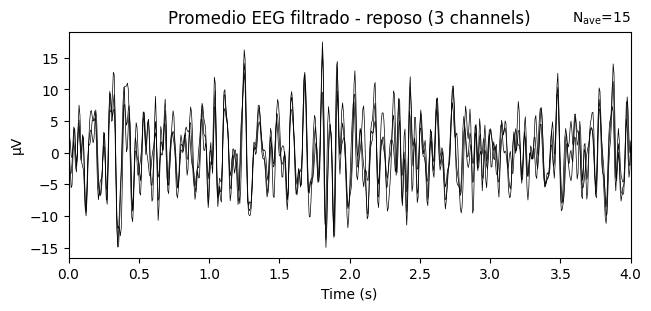

C:\Users\User\AppData\Local\Temp\ipykernel_24648\3983159942.py:3: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  evoked.plot(


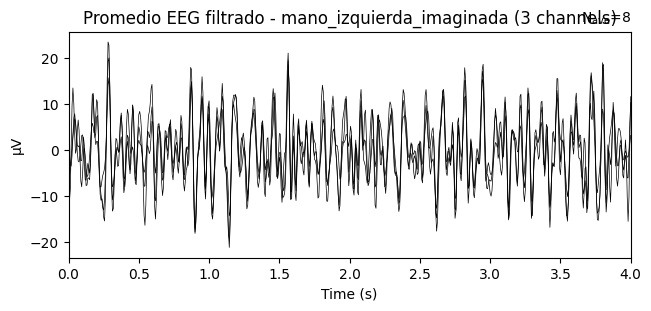

C:\Users\User\AppData\Local\Temp\ipykernel_24648\3983159942.py:3: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  evoked.plot(


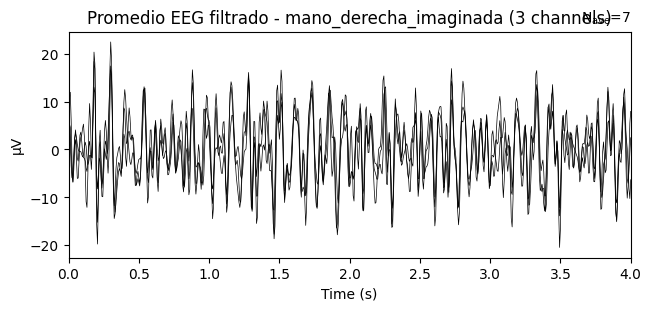

In [ ]:
for condicion in event_id.keys():
    evoked = epochs[condicion].average()
    evoked.plot(
        picks=["C3", "Cz", "C4"],
        titles=f"Promedio EEG filtrado - {condicion}",
        spatial_colors=True
    )

### Extraer información de los datos en formato numpy

In [ ]:
X = epochs.get_data()   # forma: épocas x canales x muestras
y = epochs.events[:, -1]

print('segmentos, canales, muestras')
print("Forma de X:", X.shape)
print("Forma de y:", y.shape)


segmentos, canales, muestras
Forma de X: (30, 3, 641)
Forma de y: (30,)


### Creación del dataframe por épocas

In [ ]:
id_a_condicion = {v: k for k, v in event_id.items()}

df_epochs = pd.DataFrame({
    "epoca": np.arange(len(y)),
    "codigo_evento": y,
    "condicion": [id_a_condicion[codigo] for codigo in y]
})

df_epochs.head()


,epoca,codigo_evento,condicion
0,0,1,reposo
1,1,3,mano_derecha_imaginada
2,2,1,reposo
3,3,2,mano_izquierda_imaginada
4,4,1,reposo


In [ ]:
df_epochs["condicion"].value_counts()

condicion
reposo                      15
mano_izquierda_imaginada     8
mano_derecha_imaginada       7
Name: count, dtype: int64

In [ ]:
# Se deben guardar las épocas filtradas y la información de cada época (condición, código de evento) en archivos separados para su posterior análisis.
epochs.save(
    RESULTS_DIR / "S001R04_epocas_filtradas-epo.fif",
    overwrite=True
)

df_epochs.to_csv(
    RESULTS_DIR / "S001R04_info_epocas.csv",
    index=False
)

print("Épocas guardadas correctamente.")

Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Épocas guardadas correctamente.


In [ ]:
# Creación de épocas desde la señal filtrada

events, event_id_original = mne.events_from_annotations(
    raw_filtrado,
    verbose=False
)

print("Eventos encontrados:")
print(event_id_original)

event_id = {
    "reposo": event_id_original["T0"],
    "mano_izquierda_imaginada": event_id_original["T1"],
    "mano_derecha_imaginada": event_id_original["T2"]
}

tmin = 0
tmax = 4

epochs = mne.Epochs(
    raw_filtrado,
    events,
    event_id=event_id,
    tmin=tmin,
    tmax=tmax,
    baseline=None,
    preload=True,
    verbose=False
)

print(epochs)

for condicion in event_id.keys():
    print(condicion, ":", len(epochs[condicion]))

Eventos encontrados:
{np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}
<Epochs | 30 events (all good), 0 – 4 s (baseline off), ~458 KiB, data loaded,
 'reposo': 15
 'mano_izquierda_imaginada': 8
 'mano_derecha_imaginada': 7>
reposo : 15
mano_izquierda_imaginada : 8
mano_derecha_imaginada : 7


### Definición de bandas y pares de canales 
Como ya se había mencionado, la señal de interés se produce en las bandas mu y beta que en total cubren un rango de frecuencia entre 8 y 30 Hz.

In [ ]:
bandas = {
    "mu": (8, 13),
    "beta": (13, 30)
}

pares_canales = [
    ("C3", "Cz"),
    ("C3", "C4"),
    ("Cz", "C4")
]

## Función para calcular la potencia en bandas con Welch 

El cálculo de Welch para la señal permite realizar la primera extracción de características en el dominio de la frecuencia conviertiendo una señal continua en el tiempo en valores de energía. Este método divide la señal por segmentos y calcula el espectro de cada segmento para luego promediarlos, ésto reduce el error y suaviza la gráfica.

La función "calcular_potencia_bandas()" permite dividir la señal por segmentos y busca dentro del espectro de frecuencias solo los índices que caen dentro del rango seleccionado y calcula el área bajo la curva de la densidad espectral de potencia indicando qué tan fuerte es el ritmo en ese momento. Por ejemplo, si en la banda mu se visualiza un valor bajo de potencia en el canal C4, es un indicador de que el sujeto está imaginando mover la mano izquierda debido a la desincronización ERD 

In [ ]:
def calcular_potencia_bandas(senal, sfreq, bandas):
    """
    Calcula la potencia de una señal en diferentes bandas usando Welch.

    Parámetros:
    -----------
    senal : array
        Señal de un canal en una época.
    sfreq : float
        Frecuencia de muestreo.
    bandas : dict
        Diccionario con bandas de frecuencia.

    Retorna:
    --------
    dict
        Potencia por banda.
    """

    nperseg = min(int(sfreq * 2), len(senal))

    freqs, psd = welch(
        senal,
        fs=sfreq,
        nperseg=nperseg
    )

    potencias = {}

    for nombre_banda, (fmin, fmax) in bandas.items():

        idx = (freqs >= fmin) & (freqs <= fmax)

        if np.sum(idx) == 0:
            potencias[nombre_banda] = np.nan
        else:
            potencias[nombre_banda] = np.trapz(psd[idx], freqs[idx])

    return potencias

## Función para parámetros de HJORTH

Los parámetros de Hjorth es un conjunto de 3 parámetros estadísticos utilizados para caracterizar una señal directamente en el dominio del tiempo. Esta función analiza la forma de onda y variabilidad. Los 3 parámetros consisten en:
- actividad: Representa la potencia media de la señal. Durante la sincronización (ERD) se espera ver una disminución de la amplitud en los canales motores.
- movilidad: Estimación de la frecuencia media de la señal. Si la movilidad aumenta, significa que la señal cambia rápidamente.
- Complejidad: Indica qué tan similar es la señal con una onda senosoidal pura que tiene complejidad 1. Si el cerebro tiene mucha actividad y por ende, es muy irregular, la complejidad será mayor a 1. Esta medida ayuda a diferenciar un estado de reposo que es más regular a un estado de procesamiento de movimiento que es mucho más irregular.

In [ ]:
def calcular_hjorth(senal):
    """
    Calcula los parámetros de Hjorth:
    actividad, movilidad y complejidad.
    """

    senal = np.asarray(senal)

    actividad = np.var(senal)

    derivada = np.diff(senal)
    var_derivada = np.var(derivada)

    if actividad == 0:
        movilidad = np.nan
    else:
        movilidad = np.sqrt(var_derivada / actividad)

    segunda_derivada = np.diff(derivada)
    var_segunda_derivada = np.var(segunda_derivada)

    if var_derivada == 0:
        movilidad_derivada = np.nan
    else:
        movilidad_derivada = np.sqrt(var_segunda_derivada / var_derivada)

    if movilidad == 0 or np.isnan(movilidad):
        complejidad = np.nan
    else:
        complejidad = movilidad_derivada / movilidad

    return {
        "hjorth_actividad": actividad,
        "hjorth_movilidad": movilidad,
        "hjorth_complejidad": complejidad
    }

## Función para entropía y permutación
Esta función realiza una medida de complejidad no lineal de la señal. Este se fija en el orden de los datos y qué tan predecibles es la secuencia de la señal. La función mira la relación de orden entre puntos cercanos, toma grupos de puntos definidos según el orden seleccionado que en este caso es de 3.

Si la señal es muy regular (como una onda senoidal), siempre se repiten los mismos patrones de orden. La entropía será baja (cercana a 0). Pero si la señal es caótica o ruidosa, todos los patrones posibles aparecen con la misma frecuencia. La entropía será alta (cercana a 1).

En el modelo BCI, las tareas de imaginación motora cambian en la dinámica cerebral:
- En Reposo (T0): Los ritmos suelen ser más estables y rítmicos (menor entropía).
- En Imaginación (T1/T2): Al ocurrir la desincronización (ERD), el ritmo dominante desaparece. La señal que queda en el electrodo suele ser más irregular o compleja porque hay más procesamiento de información cortical, lo que se traduce en un aumento de la entropía.

In [ ]:
def calcular_entropia_permutacion(senal, orden=3, retardo=1):
    """
    Calcula la entropía de permutación normalizada.

    Una señal más regular tendrá menor entropía.
    Una señal más irregular tendrá mayor entropía.
    """

    senal = np.asarray(senal)

    n = len(senal)
    longitud_patron = retardo * (orden - 1) + 1

    if n < longitud_patron:
        return np.nan

    patrones = []

    for i in range(n - longitud_patron + 1):
        ventana = senal[i : i + longitud_patron : retardo]
        patron = tuple(np.argsort(ventana))                     #Convierte los valores numéricos en un "patrón de rango"
        patrones.append(patron)

    patrones = np.array(patrones)

    _, conteos = np.unique(                                     #Cuenta cuántas veces aparece cada tipo de patrón en toda la señal.
        patrones,
        axis=0,
        return_counts=True
    )

    probabilidades = conteos / np.sum(conteos)                 

    entropia = -np.sum(probabilidades * np.log2(probabilidades))        ##Calcula cuánto "desorden" hay en la distribución de esos patrones.

    entropia_maxima = np.log2(factorial(orden))

    entropia_normalizada = entropia / entropia_maxima       #Divide el resultado por el máximo posible. Esto hace que el resultado siempre esté entre 0 y 1

    return entropia_normalizada

## Función de Coherencia en bandas
es una medida de conectividad funcional entre dos regiones del cerebro. A diferencia de las funciones anteriores que analizaban un solo canal (C3 o C4 de forma aislada), esta función analiza cómo se "comunican" o qué tan sincronizados están dos canales entre sí. En el contexto de sistemas BCI, se usa principalmente para medir la relación entre C3 y C4 o entre un canal motor y el canal central Cz.

- Si el valor es 1 (Coherencia alta): Indica que las dos señales tienen una relación de fase constante; es decir, están perfectamente sincronizadas en esa frecuencia.

- Si el valor es 0 (Coherencia baja): Indica que las señales son totalmente independientes la una de la otra.

Cuando se analiza la coherencia por eventos, se puede identificar que en el estado de Reposo (T0) Suele haber una coherencia basal estable entre los dos hemisferios (comunicación interhemisférica normal). Mientras que cuando hay imaginación Motora (T1/T2), por ejemplo Cuando se concentra en mover la mano izquierda, el hemisferio derecho (C4) se "desconecta" del ritmo global para procesar la tarea. Esto suele causar una caída en la coherencia entre C3 y C4 en las bandas Mu y Beta. Es como si una parte del cerebro dejara de escuchar a la otra para enfocarse en su propio trabajo.

En el modelo de Maching learning, se agrega una característica que no solo dice si hay mucha o poca energía en los canales sino que indica que los canales dejaron de estar sincronizados. 

In [ ]:
def calcular_coherencia_bandas(senal_1, senal_2, sfreq, bandas):
    """
    Calcula la coherencia entre dos canales y la resume por bandas.
    """

    nperseg = min(int(sfreq * 2), len(senal_1))

    freqs, coh = coherence(
        senal_1,
        senal_2,
        fs=sfreq,
        nperseg=nperseg
    )

    coherencias = {}

    for nombre_banda, (fmin, fmax) in bandas.items():

        idx = (freqs >= fmin) & (freqs <= fmax)

        if np.sum(idx) == 0:
            coherencias[nombre_banda] = np.nan
        else:
            coherencias[nombre_banda] = np.mean(coh[idx])

    return coherencias

### Extraer características de todas las épocas
Se busca extraer de cada run las características con las funciones antes creadas

In [ ]:
def extraer_caracteristicas_epochs(
    epochs,
    sujeto,
    run,
    tipo_tarea,
    bandas,
    pares_canales
):
    """
    Extrae características por época y por condición.

    Características calculadas:
    - Potencia en bandas mu y beta.
    - Parámetros de Hjorth.
    - Entropía de permutación.
    - Coherencia entre pares de canales.

    Retorna:
    --------
    df_caracteristicas : DataFrame
        Dataframe en formato largo.
    """

    datos = epochs.get_data()  # épocas x canales x muestras
    sfreq = epochs.info["sfreq"]
    canales = epochs.ch_names

    eventos_epocas = epochs.events[:, -1]
    id_a_condicion = {v: k for k, v in epochs.event_id.items()}

    resultados = []

    for idx_epoca in range(datos.shape[0]):

        codigo_evento = eventos_epocas[idx_epoca]
        condicion = id_a_condicion[codigo_evento]

        datos_epoca = datos[idx_epoca]

        # ====================================================
        # CARACTERÍSTICAS POR CANAL
        # ====================================================

        for idx_canal, canal in enumerate(canales):

            senal = datos_epoca[idx_canal]

            # ----------------------------
            # Potencia en bandas
            # ----------------------------

            potencias = calcular_potencia_bandas(
                senal,
                sfreq,
                bandas
            )

            for banda, valor in potencias.items():

                resultados.append({
                    "sujeto": sujeto,
                    "run": run,
                    "tipo_tarea": tipo_tarea,
                    "epoca": idx_epoca,
                    "condicion": condicion,
                    "tipo_metrica": "frecuencia",
                    "metrica": "psd",
                    "canal": canal,
                    "par_canales": "",
                    "banda": banda,
                    "valor": valor
                })

            # ----------------------------
            # Hjorth
            # ----------------------------

            hjorth = calcular_hjorth(senal)

            for nombre_metrica, valor in hjorth.items():

                resultados.append({
                    "sujeto": sujeto,
                    "run": run,
                    "tipo_tarea": tipo_tarea,
                    "epoca": idx_epoca,
                    "condicion": condicion,
                    "tipo_metrica": "temporal",
                    "metrica": nombre_metrica,
                    "canal": canal,
                    "par_canales": "",
                    "banda": "",
                    "valor": valor
                })

            # ----------------------------
            # Entropía de permutación
            # ----------------------------

            entropia = calcular_entropia_permutacion(
                senal,
                orden=3,
                retardo=1
            )

            resultados.append({
                "sujeto": sujeto,
                "run": run,
                "tipo_tarea": tipo_tarea,
                "epoca": idx_epoca,
                "condicion": condicion,
                "tipo_metrica": "no_lineal",
                "metrica": "entropia_permutacion",
                "canal": canal,
                "par_canales": "",
                "banda": "",
                "valor": entropia
            })

        # ====================================================
        # COHERENCIA ENTRE PARES DE CANALES
        # ====================================================

        for canal_1, canal_2 in pares_canales:

            if canal_1 not in canales or canal_2 not in canales:
                continue

            idx_1 = canales.index(canal_1)
            idx_2 = canales.index(canal_2)

            senal_1 = datos_epoca[idx_1]
            senal_2 = datos_epoca[idx_2]

            coherencias = calcular_coherencia_bandas(
                senal_1,
                senal_2,
                sfreq,
                bandas
            )

            for banda, valor in coherencias.items():

                resultados.append({
                    "sujeto": sujeto,
                    "run": run,
                    "tipo_tarea": tipo_tarea,
                    "epoca": idx_epoca,
                    "condicion": condicion,
                    "tipo_metrica": "conectividad",
                    "metrica": "coherencia",
                    "canal": "",
                    "par_canales": f"{canal_1}-{canal_2}",
                    "banda": banda,
                    "valor": valor
                })

    df_caracteristicas = pd.DataFrame(resultados)

    return df_caracteristicas

In [ ]:
# IDENTIFICAR SUJETO Y RUN DEL ARCHIVO ACTUAL

import re

nombre_archivo = archivo_prueba.name

coincidencia = re.search(r"(S\d{3})R(\d{2})", nombre_archivo)

if coincidencia:
    sujeto = coincidencia.group(1)
    run = "R" + coincidencia.group(2)
else:
    sujeto = "S001"
    run = "R04"

print("Archivo:", nombre_archivo)
print("Sujeto:", sujeto)
print("Run:", run)

Archivo: S001R04.edf
Sujeto: S001
Run: R04


### Aplicar la extracción de características para la clasificación 

In [ ]:
df_caracteristicas = extraer_caracteristicas_epochs(
    epochs=epochs,
    sujeto=sujeto,
    run=run,
    tipo_tarea="imaginacion_motora",
    bandas=bandas,
    pares_canales=pares_canales
)

df_caracteristicas.head()

C:\Users\User\AppData\Local\Temp\ipykernel_24648\885421631.py:37: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  potencias[nombre_banda] = np.trapz(psd[idx], freqs[idx])


,sujeto,run,tipo_tarea,epoca,condicion,tipo_metrica,metrica,canal,par_canales,banda,valor
0,S001,R04,imaginacion_motora,0,reposo,frecuencia,psd,C3,,mu,1.807449e-10
1,S001,R04,imaginacion_motora,0,reposo,frecuencia,psd,C3,,beta,1.571967e-10
2,S001,R04,imaginacion_motora,0,reposo,temporal,hjorth_actividad,C3,,,4.049913e-10
3,S001,R04,imaginacion_motora,0,reposo,temporal,hjorth_movilidad,C3,,,5.890676e-01
4,S001,R04,imaginacion_motora,0,reposo,temporal,hjorth_complejidad,C3,,,1.334187e+00


In [ ]:
# IDENTIFICAR SUJETO Y RUN DEL ARCHIVO ACTUAL

nombre_archivo = archivo_prueba.name

coincidencia = re.search(r"(S\d{3})R(\d{2})", nombre_archivo)

if coincidencia:
    sujeto = coincidencia.group(1)
    run = "R" + coincidencia.group(2)
else:
    sujeto = "S001"
    run = "R04"

print("Sujeto:", sujeto)
print("Run:", run)

Sujeto: S001
Run: R04


In [ ]:
# Revisar resumen del dataframe

print("Cantidad total de filas:", len(df_caracteristicas))

print("\nCantidad por métrica:")
print(df_caracteristicas["metrica"].value_counts())

print("\nCantidad por condición:")
print(df_caracteristicas["condicion"].value_counts())

df_caracteristicas.head(15)

Cantidad total de filas: 720

Cantidad por métrica:
metrica
psd                     180
coherencia              180
hjorth_actividad         90
hjorth_movilidad         90
hjorth_complejidad       90
entropia_permutacion     90
Name: count, dtype: int64

Cantidad por condición:
condicion
reposo                      360
mano_izquierda_imaginada    192
mano_derecha_imaginada      168
Name: count, dtype: int64


,sujeto,run,tipo_tarea,epoca,condicion,tipo_metrica,metrica,canal,par_canales,banda,valor
0,S001,R04,imaginacion_motora,0,reposo,frecuencia,psd,C3,,mu,1.807449e-10
1,S001,R04,imaginacion_motora,0,reposo,frecuencia,psd,C3,,beta,1.571967e-10
2,S001,R04,imaginacion_motora,0,reposo,temporal,hjorth_actividad,C3,,,4.049913e-10
3,S001,R04,imaginacion_motora,0,reposo,temporal,hjorth_movilidad,C3,,,5.890676e-01
4,S001,R04,imaginacion_motora,0,reposo,temporal,hjorth_complejidad,C3,,,1.334187e+00
5,S001,R04,imaginacion_motora,0,reposo,no_lineal,entropia_permutacion,C3,,,8.044480e-01
6,S001,R04,imaginacion_motora,0,reposo,frecuencia,psd,Cz,,mu,2.309914e-10
7,S001,R04,imaginacion_motora,0,reposo,frecuencia,psd,Cz,,beta,1.575416e-10
8,S001,R04,imaginacion_motora,0,reposo,temporal,hjorth_actividad,Cz,,,4.698366e-10
9,S001,R04,imaginacion_motora,0,reposo,temporal,hjorth_movilidad,Cz,,,5.804225e-01


### Guardar el dataframe de características en el pc

In [ ]:
ruta_caracteristicas = RESULTS_DIR / f"caracteristicas_{sujeto}_{run}.csv"

df_caracteristicas.to_csv(
    ruta_caracteristicas,
    index=False
)

print("Características guardadas en:")
print(ruta_caracteristicas.resolve())

Características guardadas en:
C:\Users\User\Documents\UdeA\BIOSENALES\resultados\caracteristicas_S001_R04.csv


Crear el nombre que se le va a asignar a cada característica 

In [ ]:
def crear_nombre_feature(fila):
    """
    Crea un nombre único para cada característica.
    """

    if fila["canal"] != "":
        ubicacion = fila["canal"]
    else:
        ubicacion = fila["par_canales"]

    if fila["banda"] != "":
        nombre = f"{fila['metrica']}_{ubicacion}_{fila['banda']}"
    else:
        nombre = f"{fila['metrica']}_{ubicacion}"

    return nombre

In [ ]:
df_features = df_caracteristicas.copy()

df_features["feature"] = df_features.apply(
    crear_nombre_feature,
    axis=1
)

df_features.head()

,sujeto,run,tipo_tarea,epoca,condicion,tipo_metrica,metrica,canal,par_canales,banda,valor,feature
0,S001,R04,imaginacion_motora,0,reposo,frecuencia,psd,C3,,mu,1.807449e-10,psd_C3_mu
1,S001,R04,imaginacion_motora,0,reposo,frecuencia,psd,C3,,beta,1.571967e-10,psd_C3_beta
2,S001,R04,imaginacion_motora,0,reposo,temporal,hjorth_actividad,C3,,,4.049913e-10,hjorth_actividad_C3
3,S001,R04,imaginacion_motora,0,reposo,temporal,hjorth_movilidad,C3,,,5.890676e-01,hjorth_movilidad_C3
4,S001,R04,imaginacion_motora,0,reposo,temporal,hjorth_complejidad,C3,,,1.334187e+00,hjorth_complejidad_C3


In [ ]:
# DATAFRAME ANCHO

df_features_wide = df_features.pivot_table(
    index=["sujeto", "run", "tipo_tarea", "epoca", "condicion"],
    columns="feature",
    values="valor"
).reset_index()

df_features_wide.head()

feature,sujeto,run,tipo_tarea,epoca,condicion,coherencia_C3-C4_beta,coherencia_C3-C4_mu,coherencia_C3-Cz_beta,coherencia_C3-Cz_mu,coherencia_Cz-C4_beta,...,hjorth_complejidad_Cz,hjorth_movilidad_C3,hjorth_movilidad_C4,hjorth_movilidad_Cz,psd_C3_beta,psd_C3_mu,psd_C4_beta,psd_C4_mu,psd_Cz_beta,psd_Cz_mu
0,S001,R04,imaginacion_motora,0,reposo,0.548739,0.757301,0.729471,0.866048,0.782158,...,1.395894,0.589068,0.589703,0.580423,1.571967e-10,1.807449e-10,1.326785e-10,1.820803e-10,1.575416e-10,2.309914e-10
1,S001,R04,imaginacion_motora,1,mano_derecha_imaginada,0.566131,0.672162,0.830022,0.828018,0.699684,...,1.399078,0.607403,0.606173,0.586667,1.636234e-10,1.608446e-10,1.419351e-10,1.418678e-10,1.611075e-10,1.800309e-10
2,S001,R04,imaginacion_motora,2,reposo,0.730795,0.718902,0.887473,0.847520,0.802928,...,1.359751,0.641720,0.602563,0.600881,2.217399e-10,1.649009e-10,1.369009e-10,1.043773e-10,1.998830e-10,1.619194e-10
3,S001,R04,imaginacion_motora,3,mano_izquierda_imaginada,0.592032,0.663038,0.817542,0.746038,0.800610,...,1.416300,0.624490,0.618020,0.617327,1.379234e-10,8.367593e-11,1.038181e-10,5.920273e-11,1.236169e-10,7.785471e-11
4,S001,R04,imaginacion_motora,4,reposo,0.621712,0.439694,0.762544,0.758907,0.784984,...,1.336435,0.578894,0.599775,0.596866,2.004874e-10,1.503950e-10,1.532310e-10,1.389338e-10,1.942459e-10,1.284300e-10


In [ ]:
# GUARDAR DATAFRAME ANCHO

ruta_features_wide = RESULTS_DIR / f"features_wide_{sujeto}_{run}.csv"

df_features_wide.to_csv(
    ruta_features_wide,
    index=False
)

print("Dataframe para clasificación guardado en:")
print(ruta_features_wide.resolve())

Dataframe para clasificación guardado en:
C:\Users\User\Documents\UdeA\BIOSENALES\resultados\features_wide_S001_R04.csv


# Ejecución de la línea de procesamiento para todos los sujetos de la base de datos

### 1. Procesar un archivo EDF

Procesa un archivo EDF completo:
    Lee la señal, Limpia nombres de canales, Selecciona canales de interés, Filtra entre 8 y 30 Hz, Segmenta por eventos T0, T1 y T2, y Extrae características por época.

    Retorna un dataframe con características (df_caracteristicas) el cual es un DataFrame largo con las características extraídas

In [ ]:
def procesar_archivo_edf(
    ruta_archivo,
    canales_interes=["C3", "Cz", "C4"],
    bandas=bandas,
    pares_canales=pares_canales,
    tmin=0,
    tmax=4
):

    # Identificar sujeto y run desde el nombre del archivo
    
    nombre_archivo = ruta_archivo.name

    coincidencia = re.search(r"(S\d{3})R(\d{2})", nombre_archivo)

    if coincidencia:
        sujeto = coincidencia.group(1)
        run = "R" + coincidencia.group(2)
    else:
        sujeto = "desconocido"
        run = "desconocido"

    # Leer archivo EDF
    
    raw = mne.io.read_raw_edf(
        ruta_archivo,
        preload=True,
        verbose=False
    )

    raw = limpiar_nombres_canales(raw)

    # Verificar canales disponibles
    
    canales_disponibles = [
        canal for canal in canales_interes
        if canal in raw.ch_names
    ]

    if len(canales_disponibles) < 2:
        print(f"Archivo omitido por falta de canales: {nombre_archivo}")
        return None

    raw = raw.pick(canales_disponibles)

    # Filtrar señal
    
    raw_filtrado = raw.copy().filter(
        l_freq=8,
        h_freq=30,
        fir_design="firwin",
        verbose=False
    )

    # Crear eventos desde anotaciones
    
    events, event_id_original = mne.events_from_annotations(
        raw_filtrado,
        verbose=False
    )

    eventos_requeridos = ["T0", "T1", "T2"]

    for evento in eventos_requeridos:
        if evento not in event_id_original:
            print(f"Archivo omitido porque no tiene {evento}: {nombre_archivo}")
            return None

    event_id = {
        "reposo": event_id_original["T0"],
        "mano_izquierda_imaginada": event_id_original["T1"],
        "mano_derecha_imaginada": event_id_original["T2"]
    }

    # Crear épocas
    
    epochs = mne.Epochs(
        raw_filtrado,
        events,
        event_id=event_id,
        tmin=tmin,
        tmax=tmax,
        baseline=None,
        preload=True,
        verbose=False
    )

    if len(epochs) == 0:
        print(f"Archivo omitido porque no generó épocas: {nombre_archivo}")
        return None

    # Extraer características
    
    df_caracteristicas = extraer_caracteristicas_epochs(
        epochs=epochs,
        sujeto=sujeto,
        run=run,
        tipo_tarea="imaginacion_motora",
        bandas=bandas,
        pares_canales=pares_canales
    )

    return df_caracteristicas

### 2. Procesamiento de todos los archivos de imaginación motora

In [ ]:
resultados_todos = []

for archivo in tqdm(edf_interes, desc="Procesando archivos EDF"):

    df_archivo = procesar_archivo_edf(
        ruta_archivo=archivo,
        canales_interes=["C3", "Cz", "C4"],
        bandas=bandas,
        pares_canales=pares_canales,
        tmin=0,
        tmax=4
    )

    if df_archivo is not None:
        resultados_todos.append(df_archivo)

print("Cantidad de archivos procesados correctamente:", len(resultados_todos))

Procesando archivos EDF:   0%|          | 0/327 [00:00<?, ?it/s]C:\Users\User\AppData\Local\Temp\ipykernel_24648\885421631.py:37: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  potencias[nombre_banda] = np.trapz(psd[idx], freqs[idx])
Procesando archivos EDF:   0%|          | 1/327 [00:04<22:56,  4.22s/it]C:\Users\User\AppData\Local\Temp\ipykernel_24648\885421631.py:37: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  potencias[nombre_banda] = np.trapz(psd[idx], freqs[idx])
Procesando archivos EDF:   1%|          | 2/327 [00:05<14:52,  2.75s/it]C:\Users\User\AppData\Local\Temp\ipykernel_24648\885421631.py:37: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  potencias[nombre_banda] = np.trapz(psd[idx], freqs[idx])
Procesand

Cantidad de archivos procesados correctamente: 327


### 3. Unión de los resultados de todos los archivos

In [ ]:
df_caracteristicas_todos = pd.concat(
    resultados_todos,
    ignore_index=True
)

print("Forma del dataframe final:")
print(df_caracteristicas_todos.shape)

display(df_caracteristicas_todos.head())

Forma del dataframe final:
(235584, 11)


,sujeto,run,tipo_tarea,epoca,condicion,tipo_metrica,metrica,canal,par_canales,banda,valor
0,S001,R04,imaginacion_motora,0,reposo,frecuencia,psd,C3,,mu,1.807449e-10
1,S001,R04,imaginacion_motora,0,reposo,frecuencia,psd,C3,,beta,1.571967e-10
2,S001,R04,imaginacion_motora,0,reposo,temporal,hjorth_actividad,C3,,,4.049913e-10
3,S001,R04,imaginacion_motora,0,reposo,temporal,hjorth_movilidad,C3,,,5.890676e-01
4,S001,R04,imaginacion_motora,0,reposo,temporal,hjorth_complejidad,C3,,,1.334187e+00


GUARDAR DATAFRAME LARGO FINAL

In [ ]:
ruta_caracteristicas_todos = RESULTS_DIR / "caracteristicas_todos_largo.csv"

df_caracteristicas_todos.to_csv(
    ruta_caracteristicas_todos,
    index=False
)

print("Dataframe largo guardado en:")
print(ruta_caracteristicas_todos.resolve())

Dataframe largo guardado en:
C:\Users\User\Documents\UdeA\BIOSENALES\resultados\caracteristicas_todos_largo.csv


CREAR DATAFRAME ANCHO DE TODOS LOS SUJETOS

In [ ]:
df_features_todos = df_caracteristicas_todos.copy()

df_features_todos["feature"] = df_features_todos.apply(
    crear_nombre_feature,
    axis=1
)

df_features_wide_todos = df_features_todos.pivot_table(
    index=["sujeto", "run", "tipo_tarea", "epoca", "condicion"],
    columns="feature",
    values="valor"
).reset_index()

print("Forma del dataframe ancho final:")
print(df_features_wide_todos.shape)

display(df_features_wide_todos.head())

Forma del dataframe ancho final:
(9816, 29)


feature,sujeto,run,tipo_tarea,epoca,condicion,coherencia_C3-C4_beta,coherencia_C3-C4_mu,coherencia_C3-Cz_beta,coherencia_C3-Cz_mu,coherencia_Cz-C4_beta,...,hjorth_complejidad_Cz,hjorth_movilidad_C3,hjorth_movilidad_C4,hjorth_movilidad_Cz,psd_C3_beta,psd_C3_mu,psd_C4_beta,psd_C4_mu,psd_Cz_beta,psd_Cz_mu
0,S001,R04,imaginacion_motora,0,reposo,0.548739,0.757301,0.729471,0.866048,0.782158,...,1.395894,0.589068,0.589703,0.580423,1.571967e-10,1.807449e-10,1.326785e-10,1.820803e-10,1.575416e-10,2.309914e-10
1,S001,R04,imaginacion_motora,1,mano_derecha_imaginada,0.566131,0.672162,0.830022,0.828018,0.699684,...,1.399078,0.607403,0.606173,0.586667,1.636234e-10,1.608446e-10,1.419351e-10,1.418678e-10,1.611075e-10,1.800309e-10
2,S001,R04,imaginacion_motora,2,reposo,0.730795,0.718902,0.887473,0.847520,0.802928,...,1.359751,0.641720,0.602563,0.600881,2.217399e-10,1.649009e-10,1.369009e-10,1.043773e-10,1.998830e-10,1.619194e-10
3,S001,R04,imaginacion_motora,3,mano_izquierda_imaginada,0.592032,0.663038,0.817542,0.746038,0.800610,...,1.416300,0.624490,0.618020,0.617327,1.379234e-10,8.367593e-11,1.038181e-10,5.920273e-11,1.236169e-10,7.785471e-11
4,S001,R04,imaginacion_motora,4,reposo,0.621712,0.439694,0.762544,0.758907,0.784984,...,1.336435,0.578894,0.599775,0.596866,2.004874e-10,1.503950e-10,1.532310e-10,1.389338e-10,1.942459e-10,1.284300e-10


In [ ]:
#GUARDAR DATAFRAME ANCHO FINAL

ruta_features_wide_todos = RESULTS_DIR / "features_wide_todos.csv"

df_features_wide_todos.to_csv(
    ruta_features_wide_todos,
    index=False
)

print("Dataframe ancho guardado en:")
print(ruta_features_wide_todos.resolve())

Dataframe ancho guardado en:
C:\Users\User\Documents\UdeA\BIOSENALES\resultados\features_wide_todos.csv


In [ ]:
print("Cantidad de archivos EDF de interés:", len(edf_interes))

#for archivo in edf_interes[:15]:
#    print(archivo.name)

Cantidad de archivos EDF de interés: 327
S001R04.edf
S001R08.edf
S001R12.edf
S002R04.edf
S002R08.edf
S002R12.edf
S003R04.edf
S003R08.edf
S003R12.edf
S004R04.edf
S004R08.edf
S004R12.edf
S005R04.edf
S005R08.edf
S005R12.edf


In [ ]:
print("Sujetos procesados:")
print(df_caracteristicas_todos["sujeto"].nunique())

print("\nLista de sujetos:")
print(sorted(df_caracteristicas_todos["sujeto"].unique()))

print("\nRuns procesados:")
print(df_caracteristicas_todos["run"].value_counts())

print("\nCondiciones:")
print(df_caracteristicas_todos["condicion"].value_counts())

Sujetos procesados:
109

Lista de sujetos:
['S001', 'S002', 'S003', 'S004', 'S005', 'S006', 'S007', 'S008', 'S009', 'S010', 'S011', 'S012', 'S013', 'S014', 'S015', 'S016', 'S017', 'S018', 'S019', 'S020', 'S021', 'S022', 'S023', 'S024', 'S025', 'S026', 'S027', 'S028', 'S029', 'S030', 'S031', 'S032', 'S033', 'S034', 'S035', 'S036', 'S037', 'S038', 'S039', 'S040', 'S041', 'S042', 'S043', 'S044', 'S045', 'S046', 'S047', 'S048', 'S049', 'S050', 'S051', 'S052', 'S053', 'S054', 'S055', 'S056', 'S057', 'S058', 'S059', 'S060', 'S061', 'S062', 'S063', 'S064', 'S065', 'S066', 'S067', 'S068', 'S069', 'S070', 'S071', 'S072', 'S073', 'S074', 'S075', 'S076', 'S077', 'S078', 'S079', 'S080', 'S081', 'S082', 'S083', 'S084', 'S085', 'S086', 'S087', 'S088', 'S089', 'S090', 'S091', 'S092', 'S093', 'S094', 'S095', 'S096', 'S097', 'S098', 'S099', 'S100', 'S101', 'S102', 'S103', 'S104', 'S105', 'S106', 'S107', 'S108', 'S109']

Runs procesados:
run
R04    78624
R12    78552
R08    78408
Name: count, dtype: int

## REALIZAR GRÁFICAS Y ML NECESARIOS PARA EL ANÁLISIS DEL PROYECTO

### Verificar el dataframe final para el análisis

In [ ]:
print("Forma del dataframe ancho final:")
print(df_features_wide_todos.shape)

print("\nPrimeras filas:")
display(df_features_wide_todos.head())

print("\nCondiciones disponibles:")
print(df_features_wide_todos["condicion"].value_counts())

print("\nSujetos disponibles:")
print(df_features_wide_todos["sujeto"].nunique())

print("\nRuns disponibles:")
print(df_features_wide_todos["run"].value_counts())

Forma del dataframe ancho final:
(9816, 29)

Primeras filas:


feature,sujeto,run,tipo_tarea,epoca,condicion,coherencia_C3-C4_beta,coherencia_C3-C4_mu,coherencia_C3-Cz_beta,coherencia_C3-Cz_mu,coherencia_Cz-C4_beta,...,hjorth_complejidad_Cz,hjorth_movilidad_C3,hjorth_movilidad_C4,hjorth_movilidad_Cz,psd_C3_beta,psd_C3_mu,psd_C4_beta,psd_C4_mu,psd_Cz_beta,psd_Cz_mu
0,S001,R04,imaginacion_motora,0,reposo,0.548739,0.757301,0.729471,0.866048,0.782158,...,1.395894,0.589068,0.589703,0.580423,1.571967e-10,1.807449e-10,1.326785e-10,1.820803e-10,1.575416e-10,2.309914e-10
1,S001,R04,imaginacion_motora,1,mano_derecha_imaginada,0.566131,0.672162,0.830022,0.828018,0.699684,...,1.399078,0.607403,0.606173,0.586667,1.636234e-10,1.608446e-10,1.419351e-10,1.418678e-10,1.611075e-10,1.800309e-10
2,S001,R04,imaginacion_motora,2,reposo,0.730795,0.718902,0.887473,0.847520,0.802928,...,1.359751,0.641720,0.602563,0.600881,2.217399e-10,1.649009e-10,1.369009e-10,1.043773e-10,1.998830e-10,1.619194e-10
3,S001,R04,imaginacion_motora,3,mano_izquierda_imaginada,0.592032,0.663038,0.817542,0.746038,0.800610,...,1.416300,0.624490,0.618020,0.617327,1.379234e-10,8.367593e-11,1.038181e-10,5.920273e-11,1.236169e-10,7.785471e-11
4,S001,R04,imaginacion_motora,4,reposo,0.621712,0.439694,0.762544,0.758907,0.784984,...,1.336435,0.578894,0.599775,0.596866,2.004874e-10,1.503950e-10,1.532310e-10,1.389338e-10,1.942459e-10,1.284300e-10



Condiciones disponibles:
condicion
reposo                      4918
mano_izquierda_imaginada    2470
mano_derecha_imaginada      2428
Name: count, dtype: int64

Sujetos disponibles:
109

Runs disponibles:
run
R04    3276
R12    3273
R08    3267
Name: count, dtype: int64


Identificación de columnas características

In [ ]:
columnas_info = [
    "tipo_tarea",
    "epoca",
    "condicion"
]

columnas_features = [
    col for col in df_features_wide_todos.columns
    if col not in columnas_info
]

print("Cantidad de características:", len(columnas_features))

print("\nPrimeras características:")
print(columnas_features[:20])

Cantidad de características: 24

Primeras características:
['coherencia_C3-C4_beta', 'coherencia_C3-C4_mu', 'coherencia_C3-Cz_beta', 'coherencia_C3-Cz_mu', 'coherencia_Cz-C4_beta', 'coherencia_Cz-C4_mu', 'entropia_permutacion_C3', 'entropia_permutacion_C4', 'entropia_permutacion_Cz', 'hjorth_actividad_C3', 'hjorth_actividad_C4', 'hjorth_actividad_Cz', 'hjorth_complejidad_C3', 'hjorth_complejidad_C4', 'hjorth_complejidad_Cz', 'hjorth_movilidad_C3', 'hjorth_movilidad_C4', 'hjorth_movilidad_Cz', 'psd_C3_beta', 'psd_C3_mu']


### Estadística descriptiva por condición 

In [ ]:
df_descriptiva = df_features_wide_todos.groupby("condicion")[columnas_features].agg(
    ["mean", "median", "std", "min", "max", "count"]
)

df_descriptiva

feature                  coherencia_C3-C4_beta                                \
                                          mean    median       std       min   
condicion                                                                      
mano_derecha_imaginada                0.590055  0.587165  0.109281  0.242047   
mano_izquierda_imaginada              0.595281  0.596225  0.108552  0.260478   
reposo                                0.573352  0.571922  0.108961  0.240081   

feature                                  coherencia_C3-C4_mu            \
                               max count                mean    median   
condicion                                                                
mano_derecha_imaginada    0.914671  2428            0.662752  0.676346   
mano_izquierda_imaginada  0.905898  2470            0.666463  0.678920   
reposo                    0.946264  4918            0.641165  0.648351   

feature                                       ...   psd_Cz_beta                \
                               std       min  ...           std           min   
condicion                                     ...                               
mano_derecha_imaginada    0.132937  0.219859  ...  1.436927e-10  2.451267e-12   
mano_izquierda_imaginada  0.129986  0.191780  ...  1.563674e-10  2.471873e-12   
reposo                    0.138193  0.205941  ...  1.598068e-10  2.846295e-12   

feature                                          psd_Cz_mu                \
                                   max count          mean        median   
condicion                                                                  
mano_derecha_imaginada    9.988152e-10  2428  1.953703e-10  1.130742e-10   
mano_izquierda_imaginada  2.974773e-09  2470  1.877434e-10  1.078603e-10   
reposo                    1.821885e-09  4918  2.168640e-10  1.192513e-10   

feature                                                                   
                                   std           min           max count  
condicion                                                                 
mano_derecha_imaginada    2.721929e-10  1.286177e-12  3.091231e-09  2428  
mano_izquierda_imaginada  2.589410e-10  1.689627e-12  3.037012e-09  2470  
reposo                    3.478476e-10  1.612099e-12  6.245691e-09  4918  

[3 rows x 144 columns]

In [ ]:
ruta_descriptiva = RESULTS_DIR / "estadistica_descriptiva_por_condicion.csv"

df_descriptiva.to_csv(ruta_descriptiva)

print("Estadística descriptiva guardada en:")
print(ruta_descriptiva.resolve())

Estadística descriptiva guardada en:
C:\Users\User\Documents\UdeA\BIOSENALES\resultados\estadistica_descriptiva_por_condicion.csv


### Selección de algunas características para graficar

Se van a graficar para comparar de forma visual características como la densidad espectral de potencia, entropía, coherencia y Hjorth

In [ ]:
features_a_graficar = [
    "psd_C3_mu",
    "psd_C4_mu",
    "psd_C3_beta",
    "psd_C4_beta",
    "hjorth_actividad_C3",
    "hjorth_actividad_C4",
    "entropia_permutacion_C3",
    "entropia_permutacion_C4",
    "coherencia_C3-C4_mu",
    "coherencia_C3-C4_beta"
]

features_a_graficar = [
    feature for feature in features_a_graficar
    if feature in df_features_wide_todos.columns
]

print("Características que sí existen en el dataframe:")
print(features_a_graficar)

Características que sí existen en el dataframe:
['psd_C3_mu', 'psd_C4_mu', 'psd_C3_beta', 'psd_C4_beta', 'hjorth_actividad_C3', 'hjorth_actividad_C4', 'entropia_permutacion_C3', 'entropia_permutacion_C4', 'coherencia_C3-C4_mu', 'coherencia_C3-C4_beta']


<Figure size 800x500 with 0 Axes>

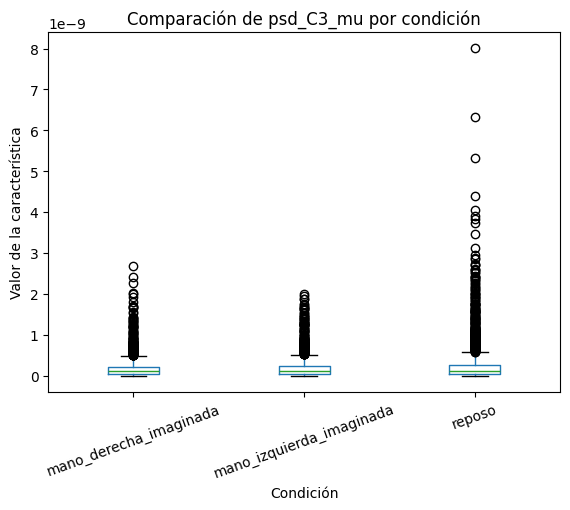

<Figure size 800x500 with 0 Axes>

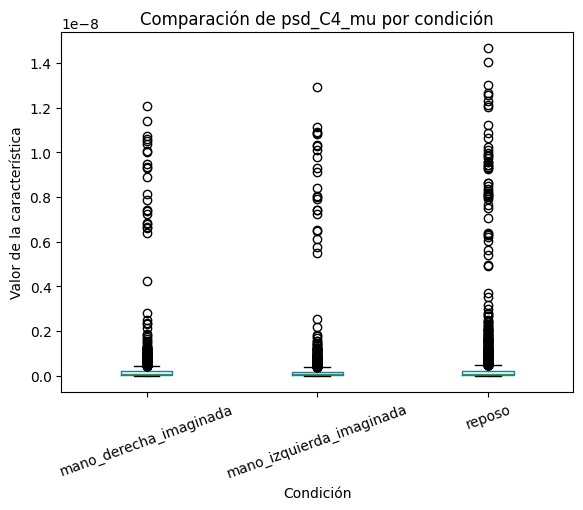

<Figure size 800x500 with 0 Axes>

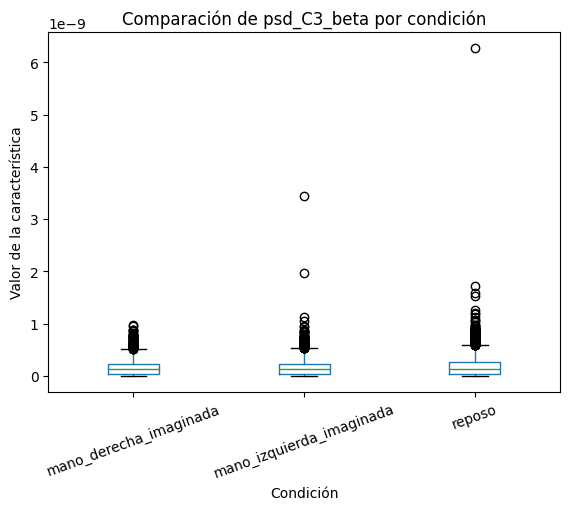

<Figure size 800x500 with 0 Axes>

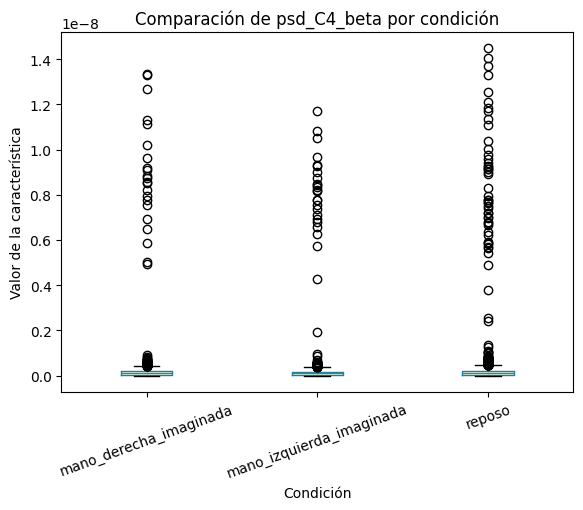

<Figure size 800x500 with 0 Axes>

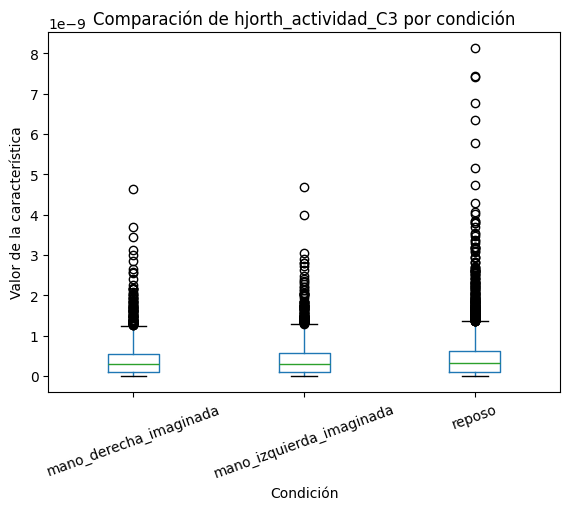

<Figure size 800x500 with 0 Axes>

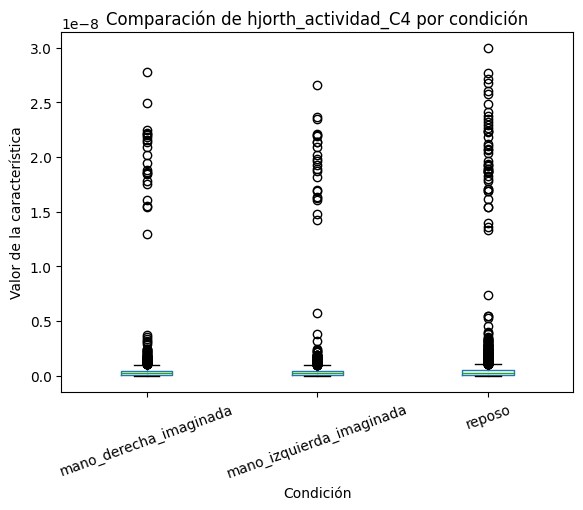

<Figure size 800x500 with 0 Axes>

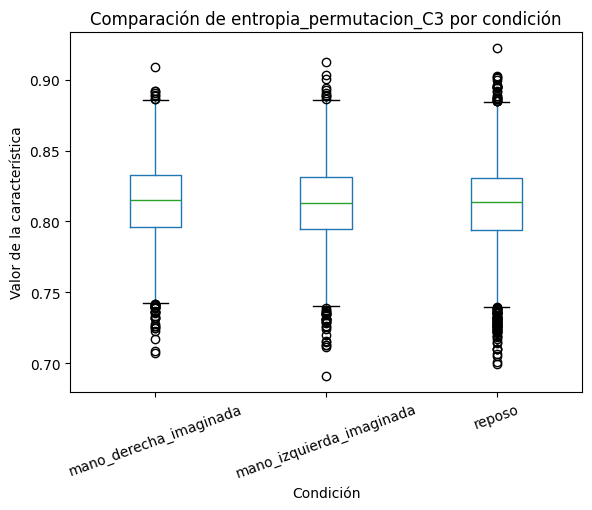

<Figure size 800x500 with 0 Axes>

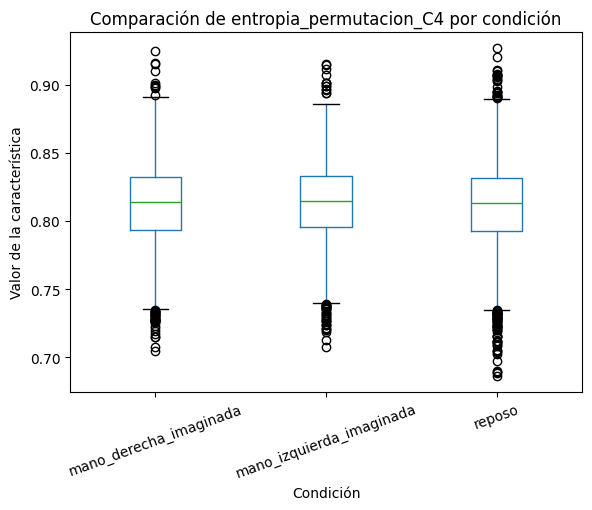

<Figure size 800x500 with 0 Axes>

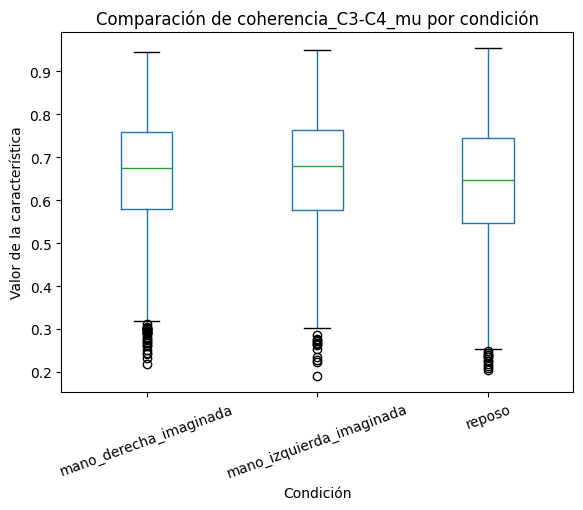

<Figure size 800x500 with 0 Axes>

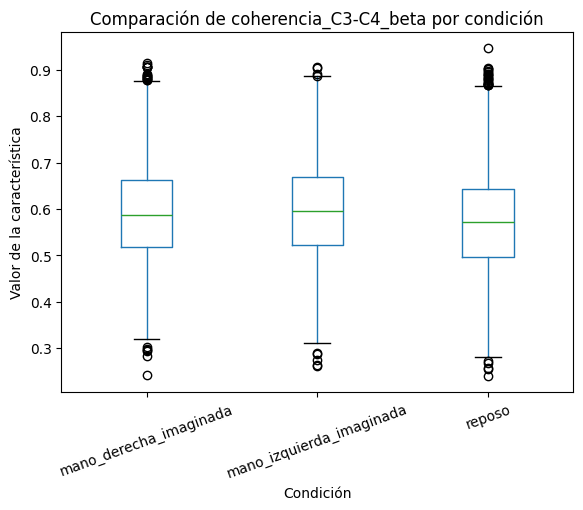

In [ ]:
# BOXPLOTS POR CONDICIÓN
# no se van a graficar en este momento para que github no ponga problema al procesar el archivo al ser muy extenso

"""
for feature in features_a_graficar:

    plt.figure(figsize=(8, 5))

    df_features_wide_todos.boxplot(
        column=feature,
        by="condicion",
        grid=False
    )

    plt.title(f"Comparación de {feature} por condición")
    plt.suptitle("")
    plt.xlabel("Condición")
    plt.ylabel("Valor de la característica")
    plt.xticks(rotation=20)
    plt.show()
"""

## Planteamiento de hipótesis

Para comparar las condiciones de reposo, imaginación de movimiento de mano izquierda e imaginación de movimiento de mano derecha, se plantean las siguientes hipótesis:

**Hipótesis nula (H0):**  
No existen diferencias estadísticamente significativas en el valor del índice EEG evaluado entre las condiciones de reposo, imaginación de mano izquierda e imaginación de mano derecha.

**Hipótesis alternativa (H1):**  
Existe al menos una diferencia estadísticamente significativa en el valor del índice EEG evaluado entre las condiciones de reposo, imaginación de mano izquierda e imaginación de mano derecha.

Como las señales EEG suelen presentar alta variabilidad entre sujetos y no se puede asumir inicialmente normalidad en la distribución de las características, se propone usar una prueba no paramétrica de **Kruskal-Wallis** para comparar las tres condiciones.

## Kruskal-Wallis para todas las características e identificación de las características más significativas para el modelo de machine learning

In [ ]:
from scipy.stats import kruskal

resultados_pruebas = []

condiciones = df_features_wide_todos["condicion"].unique()

for feature in columnas_features:

    grupos = []

    for condicion in condiciones:
        valores = df_features_wide_todos.loc[
            df_features_wide_todos["condicion"] == condicion,
            feature
        ].dropna()

        grupos.append(valores)

    # Solo aplicar si cada grupo tiene datos suficientes
    if all(len(grupo) > 1 for grupo in grupos):

        estadistico, p_valor = kruskal(*grupos)

        resultados_pruebas.append({
            "feature": feature,
            "estadistico_kruskal": estadistico,
            "p_valor": p_valor
        })

df_pruebas = pd.DataFrame(resultados_pruebas)

df_pruebas = df_pruebas.sort_values(
    by="p_valor",
    ascending=True
).reset_index(drop=True)

# df_pruebas.head(20)

#----------------------------------------------------------------

alpha = 0.05

df_pruebas["significativa"] = df_pruebas["p_valor"] < alpha

print("Cantidad de características significativas:")
print(df_pruebas["significativa"].sum())

display(df_pruebas.head(20))

,feature,estadistico_kruskal,p_valor
0,coherencia_Cz-C4_mu,98.199343,4.745518e-22
1,coherencia_C3-Cz_mu,92.752077,7.230067e-21
2,coherencia_C3-C4_beta,85.036886,3.423535e-19
3,coherencia_C3-C4_mu,75.096148,4.932631e-17
4,coherencia_Cz-C4_beta,69.264170,9.109122e-16
5,coherencia_C3-Cz_beta,68.165729,1.577611e-15
6,psd_C4_mu,31.734888,1.284862e-07
7,psd_C3_mu,28.687014,5.897855e-07
8,hjorth_complejidad_C3,20.968745,2.797016e-05
9,psd_C3_beta,19.626382,5.472494e-05


## Selección de características con mayor diferencia entre condiciones

In [ ]:
top_features = df_pruebas.loc[
    df_pruebas["significativa"] == True,
    "feature"
].head(15).tolist()

print("Top características seleccionadas:")
for feature in top_features:
    print(feature)

Top características seleccionadas:
coherencia_Cz-C4_mu
coherencia_C3-Cz_mu
coherencia_C3-C4_beta
coherencia_C3-C4_mu
coherencia_Cz-C4_beta
coherencia_C3-Cz_beta
psd_C4_mu
psd_C3_mu
hjorth_complejidad_C3
psd_C3_beta
hjorth_complejidad_Cz
hjorth_actividad_C3
hjorth_actividad_C4
psd_C4_beta
psd_Cz_mu


## Gráfica de cajas y bigotes de las características más significativas

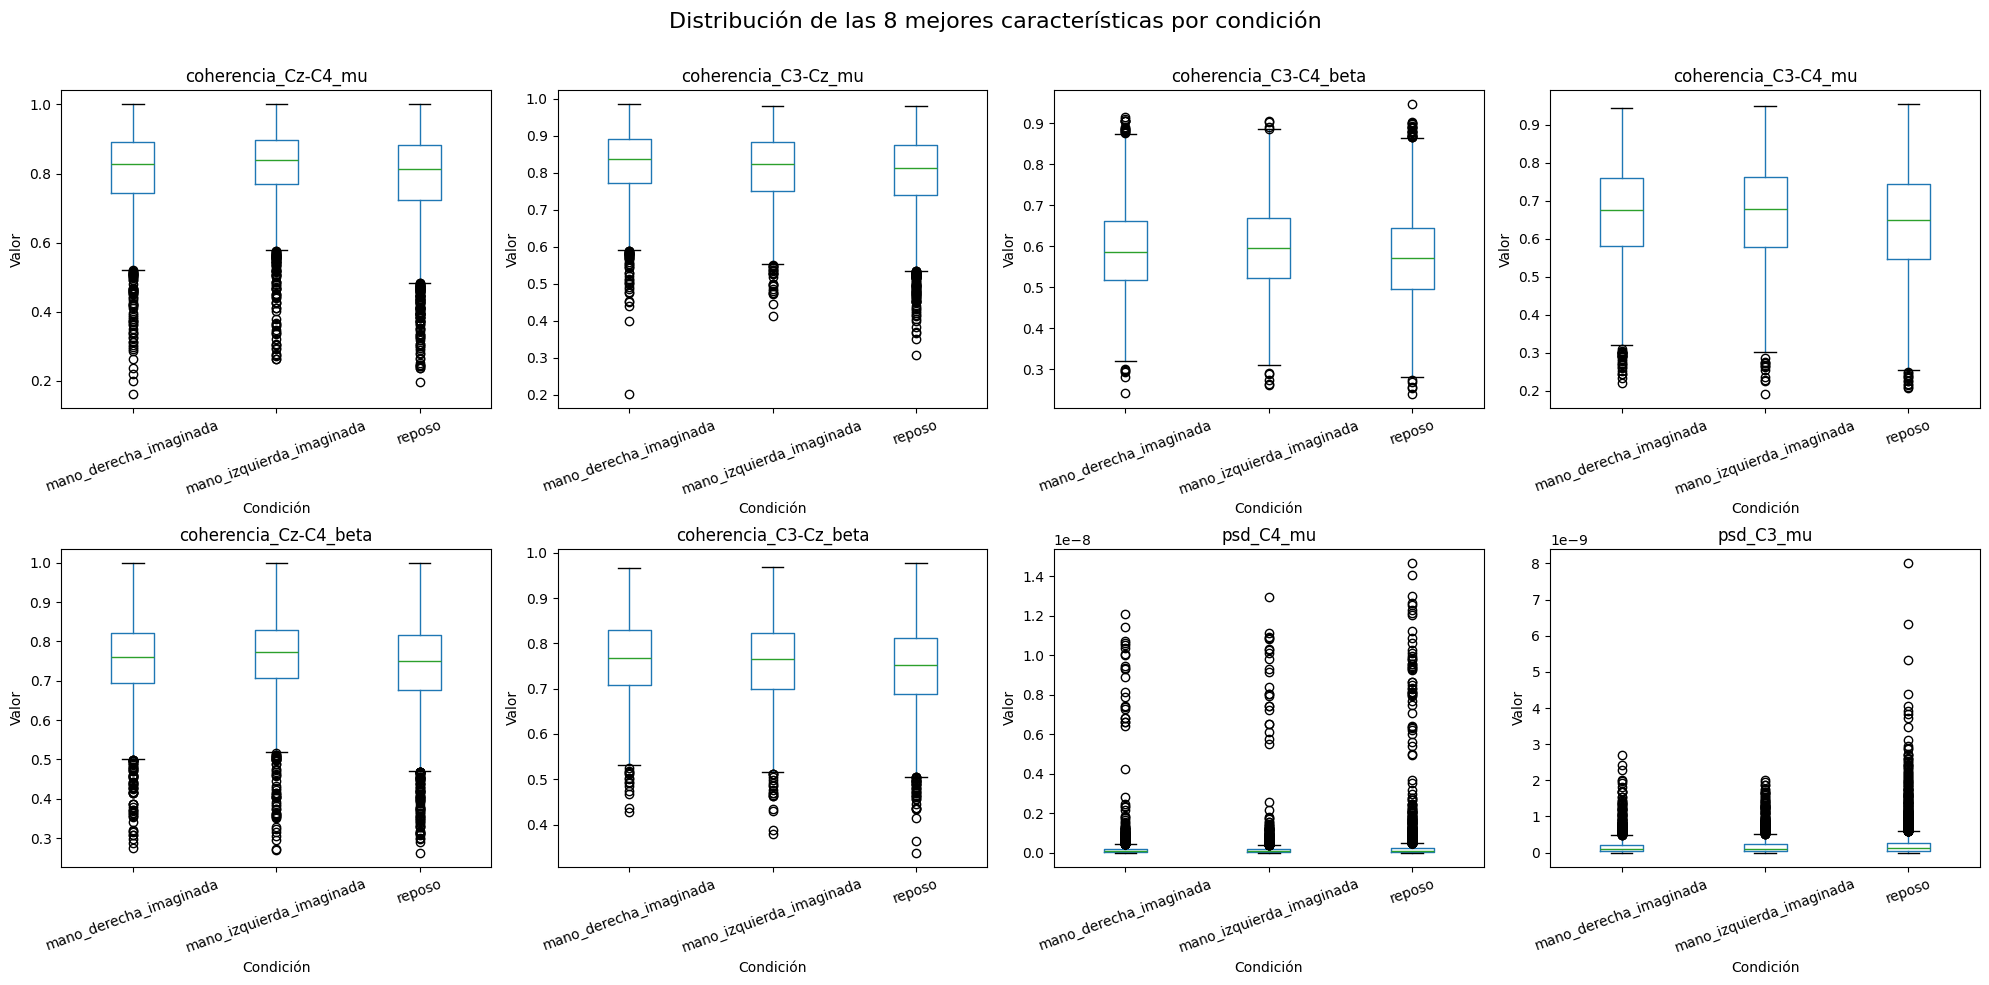

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()  # Convertimos la matriz de ejes en una lista plana para iterar fácil

for i, feature in enumerate(top_features[:8]):
    df_features_wide_todos.boxplot(
        column=feature,
        by="condicion",
        grid=False,
        ax=axes[i]  
    )

    axes[i].set_title(f"{feature}")
    axes[i].set_xlabel("Condición")
    axes[i].set_ylabel("Valor")
    axes[i].tick_params(axis='x', rotation=20)

plt.suptitle("Distribución de las 8 mejores características por condición", fontsize=16)
plt.tight_layout() 
plt.subplots_adjust(top=0.9) 
plt.show()

In [ ]:
pip -q install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Preparación del pipeline de clasificación con CSP + Lateralización

In [ ]:
# Importaciones adicionales para la clasificación

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.base import clone
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from mne.decoding import CSP
from scipy.signal import welch
import re


## Extracción de épocas en formato NumPy para CSP

El CSP requiere los datos en formato `(épocas × canales × muestras)`, no en DataFrame.
Por eso recorremos de nuevo los archivos EDF y acumulamos directamente los arrays NumPy,
**sin guardar el sujeto** como columna. Solo importa la condición (etiqueta de movimiento).

**Acumular épocas y etiquetas de todos los sujetos** (no va a tomar en cuenta a qué sujeto pertenece cada época ya que solo interesa la etiqueta de movimiento)

In [ ]:
todas_epocas   = []   # lista de arrays (canales x muestras) por época
todas_etiquetas = []  # lista de strings: 'reposo', 'mano_izquierda_imaginada', 'mano_derecha_imaginada'

for ruta_archivo in tqdm(edf_interes, desc="Extrayendo épocas"):

    nombre_archivo = ruta_archivo.name
    coincidencia = re.search(r"(S\d{3})R(\d{2})", nombre_archivo)
    if not coincidencia:
        continue

    try:
        raw_s = mne.io.read_raw_edf(ruta_archivo, preload=True, verbose=False)
        raw_s = limpiar_nombres_canales(raw_s)

        canales_disp = [c for c in ["C3", "Cz", "C4"] if c in raw_s.ch_names]
        if len(canales_disp) < 2:
            continue

        raw_s = raw_s.pick(canales_disp)
        raw_s.filter(l_freq=8, h_freq=30, fir_design="firwin", verbose=False)

        events_s, event_id_s = mne.events_from_annotations(raw_s, verbose=False)

        if not all(t in event_id_s for t in ["T0", "T1", "T2"]):
            continue

        event_id_map = {
            "reposo":                  event_id_s["T0"],
            "mano_izquierda_imaginada": event_id_s["T1"],
            "mano_derecha_imaginada":   event_id_s["T2"]
        }

        epochs_s = mne.Epochs(
            raw_s, events_s,
            event_id=event_id_map,
            tmin=0, tmax=4,
            baseline=None,
            preload=True, verbose=False
        )

        if len(epochs_s) == 0:
            continue

        datos_s  = epochs_s.get_data()          # (n_epocas, n_canales, n_muestras)
        labels_s = epochs_s.events[:, -1]
        id2name  = {v: k for k, v in epochs_s.event_id.items()}

        for idx_ep in range(datos_s.shape[0]):
            todas_epocas.append(datos_s[idx_ep])           # (canales, muestras)
            todas_etiquetas.append(id2name[labels_s[idx_ep]])

    except Exception as e:
        print(f"Error en {nombre_archivo}: {e}")
        continue

print(f"\nTotal de épocas acumuladas: {len(todas_epocas)}")
print("Distribución de clases:")
for cls in ["reposo", "mano_izquierda_imaginada", "mano_derecha_imaginada"]:
    n = todas_etiquetas.count(cls)
    print(f"  {cls}: {n}")


Extrayendo épocas:  91%|█████████ | 296/327 [00:15<00:01, 21.84it/s]C:\Users\User\AppData\Local\Temp\ipykernel_24648\2312448376.py:18: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw_s = mne.io.read_raw_edf(ruta_archivo, preload=True, verbose=False)
C:\Users\User\AppData\Local\Temp\ipykernel_24648\2312448376.py:18: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw_s = mne.io.read_raw_edf(ruta_archivo, preload=True, verbose=False)
Extrayendo épocas:  91%|█████████▏| 299/327 [00:15<00:01, 18.74it/s]C:\Users\User\AppData\Local\Temp\ipykernel_24648\2312448376.py:18: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw_s = mne.io.read_raw_edf(ruta_archivo, preload=True, verbose=False)
Extrayendo épocas: 100%|██████████| 327/327 [00:16<00:00, 19.42it/s]


Total de épocas acumuladas: 9816
Distribución de clases:
  reposo: 4918
  mano_izquierda_imaginada: 2470
  mano_derecha_imaginada: 2428


## Conversión a arrays NumPy y codificación de etiquetas

Aquí se eliminan definitivamente los metadatos de sujeto.
La matriz `X_raw` tiene forma `(épocas, canales, muestras)` y `y` son enteros 0/1/2.


In [ ]:
X_raw = np.array(todas_epocas)          # (N_epocas, n_canales, n_muestras)
le    = LabelEncoder()
y_all = le.fit_transform(todas_etiquetas)
nombres_clases = list(le.classes_)

print("Shape X_raw:", X_raw.shape)
print("Shape y_all:", y_all.shape)
print("Clases y codificación:", dict(zip(le.classes_, le.transform(le.classes_))))


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (9816, 3) + inhomogeneous part.

## Extracción de características: CSP + Índice de lateralización

Se combinan dos tipos de features:

1. **CSP (Common Spatial Patterns)** — estrategia One-vs-Rest para 3 clases.
   Cada clasificador CSP binario encuentra filtros espaciales que maximizan la varianza
   de una clase vs las demás. Se usan 4 componentes por clasificador → 12 features en total.

2. **Índice de lateralización hemisférica (log-ratio C4/C3)** en bandas mu y beta.
   Captura directamente la asimetría ERD/ERS entre hemisferios durante imaginería motora.
   → 2 features adicionales.

**Total: 14 features por época**, sin ningún dato de sujeto.


### Extracción de CSP descrito en el plan de análisis y lateralización

In [ ]:
def extraer_features_csp_lateral(X_raw, y_all, sfreq=160.0, n_components=4):
    """
    Extrae features CSP (One-vs-Rest) + índice de lateralización mu/beta.

    Parámetros:
    -----------
    X_raw       : array (N, canales, muestras)
    y_all       : array (N,) con etiquetas numéricas
    sfreq       : frecuencia de muestreo
    n_components: componentes CSP por clasificador binario

    Retorna:
    --------
    X_features  : array (N, n_components*n_clases + 2)
    """

    clases_unicas = np.unique(y_all)
    features_csp  = []

    # ── CSP One-vs-Rest ──────────────────────────────────────
    for clase in clases_unicas:
        y_bin = (y_all == clase).astype(int)

        csp = CSP(n_components=n_components, reg=0.1, log=True, norm_trace=False)
        try:
            csp.fit(X_raw, y_bin)
            feats = csp.transform(X_raw)        # (N, n_components)
        except Exception:
            feats = np.zeros((X_raw.shape[0], n_components))

        features_csp.append(feats)

    X_csp = np.hstack(features_csp)            # (N, n_components * n_clases)

    # ── Índice de lateralización log(C4/C3) por banda ───────
    # Asumimos orden de canales: C3=0, Cz=1, C4=2
    # (igual que en el pipeline de extracción original)
    bandas = {"mu": (8, 13), "beta": (13, 30)}
    lat_features = []

    for idx_ep in range(X_raw.shape[0]):
        lat_ep = []
        for fmin, fmax in bandas.values():
            nperseg = min(int(sfreq * 2), X_raw.shape[2])

            _, psd_c3 = welch(X_raw[idx_ep, 0], fs=sfreq, nperseg=nperseg)
            _, psd_c4 = welch(X_raw[idx_ep, 2 if X_raw.shape[1] > 2 else -1],
            fs=sfreq, nperseg=nperseg)

            freqs_w, _ = welch(X_raw[idx_ep, 0], fs=sfreq, nperseg=nperseg)
            idx_b = (freqs_w >= fmin) & (freqs_w <= fmax)

            pot_c3 = np.trapezoid(psd_c3[idx_b], freqs_w[idx_b]) if idx_b.any() else 1e-10
            pot_c4 = np.trapezoid(psd_c4[idx_b], freqs_w[idx_b]) if idx_b.any() else 1e-10

            ratio = np.log(pot_c4 + 1e-10) - np.log(pot_c3 + 1e-10)
            lat_ep.append(ratio)

        lat_features.append(lat_ep)

    X_lat = np.array(lat_features)             # (N, 2)

    return np.hstack([X_csp, X_lat])           # (N, 14)


Extracción de características

In [ ]:
# Obtención de la frecuencia de muestreo del último archivo procesado
sfreq_global = 160   # Hz estándar del dataset PhysioNet EEG Motor

X_features = extraer_features_csp_lateral(X_raw, y_all, sfreq=sfreq_global, n_components=4)

print("Shape final de features:", X_features.shape)
print(f"  → {X_features.shape[1]} features por época")
print(f"  → {X_features.shape[0]} épocas totales")


## Aleatorización y división entrenamiento/prueba

Se usa `StratifiedShuffleSplit` que:
- **Mezcla completamente** todas las épocas antes de separar (no hay orden por sujeto).
- **Mantiene la proporción de clases** igual en train y test en cada fold.
- Es más robusto que `StratifiedKFold` para este caso porque el shuffle es total.

Al no tener la columna de sujeto en la matriz, el modelo no puede aprender
a identificar sujetos — solo aprende patrones de movimiento.


In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

n_splits  = 5
test_size = 0.2    # 80% entrenamiento / 20% prueba por fold

sss = StratifiedShuffleSplit(
    n_splits=n_splits,
    test_size=test_size,
    random_state=42
)

print(f"Estrategia: StratifiedShuffleSplit")
print(f"  Folds     : {n_splits}")
print(f"  Test size : {test_size*100:.0f}%  ({int(len(y_all)*test_size)} épocas aprox.)")
print(f"  Train size: {(1-test_size)*100:.0f}% ({int(len(y_all)*(1-test_size))} épocas aprox.)")

# Verificar distribución de clases
print("\nDistribución de clases en y_all:")
for nombre, codigo in zip(nombres_clases, range(len(nombres_clases))):
    print(f"  {nombre}: {np.sum(y_all == codigo)}")


## Función de evaluación con K-fold

In [ ]:
def evaluar_modelo(nombre_modelo, modelo, X, y, cv, nombres_clases, usar_escalado=True):        #FUNCIÓN GENERAL PARA EVALUAR MODELOS
    """
    Evalúa un modelo con validación cruzada.
    Retorna accuracy, F1-macro y matriz de confusión acumulada.
    """

    accuracies = []
    f1_scores  = []
    y_real_total = []
    y_pred_total = []

    for fold, (idx_train, idx_test) in enumerate(cv.split(X, y), start=1):

        X_train, X_test = X[idx_train], X[idx_test]
        y_train, y_test = y[idx_train], y[idx_test]

        if usar_escalado:
            clf = Pipeline([
                ("scaler", StandardScaler()),
                ("modelo", clone(modelo))
            ])
        else:
            clf = clone(modelo)

        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        f1  = f1_score(y_test, y_pred, average="macro")

        accuracies.append(acc)
        f1_scores.append(f1)
        y_real_total.extend(y_test)
        y_pred_total.extend(y_pred)

        print(f"  Fold {fold}: Accuracy={acc:.4f}  F1-macro={f1:.4f}")

    matriz  = confusion_matrix(y_real_total, y_pred_total)
    reporte = classification_report(
        y_real_total, y_pred_total,
        target_names=nombres_clases, output_dict=True
    )

    print(f"\n  ── {nombre_modelo} ──")
    print(f"  Accuracy promedio : {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
    print(f"  F1-macro promedio : {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")

    return {
        "modelo":             nombre_modelo,
        "accuracy_promedio":  np.mean(accuracies),
        "accuracy_std":       np.std(accuracies),
        "f1_macro_promedio":  np.mean(f1_scores),
        "f1_macro_std":       np.std(f1_scores),
        "matriz_confusion":   matriz,
        "reporte":            reporte
    }


### Función que grafica la matriz de confusión evaluar qué tan bien se predice la clasificación

In [ ]:
def graficar_matriz_confusion(matriz, nombres_clases, titulo):

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(matriz, cmap="Blues")
    plt.colorbar(im, ax=ax)

    ax.set_xticks(np.arange(len(nombres_clases)))
    ax.set_yticks(np.arange(len(nombres_clases)))
    ax.set_xticklabels(nombres_clases, rotation=30, ha="right", fontsize=9)
    ax.set_yticklabels(nombres_clases, fontsize=9)
    ax.set_xlabel("Clase predicha")
    ax.set_ylabel("Clase real")
    ax.set_title(titulo, fontsize=11)

    # Anotaciones con valor y porcentaje por fila
    totales_fila = matriz.sum(axis=1, keepdims=True)
    for i in range(matriz.shape[0]):
        for j in range(matriz.shape[1]):
            pct = 100 * matriz[i, j] / totales_fila[i, 0] if totales_fila[i, 0] > 0 else 0
            color = "white" if matriz[i, j] > matriz.max() / 2 else "black"
            ax.text(j, i, f"{matriz[i,j]}\n({pct:.1f}%)",
                    ha="center", va="center", color=color, fontsize=8)

    plt.tight_layout()
    plt.show()


## Modelo 1: SVM con kernel RBF

In [ ]:
# class_weight='balanced' para no ignorar clases minoritarias

modelo_svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    class_weight="balanced",
    random_state=42
)

print("=== SVM RBF ===")
resultados_svm = evaluar_modelo(
    nombre_modelo="SVM RBF",
    modelo=modelo_svm,
    X=X_features,
    y=y_all,
    cv=sss,
    nombres_clases=nombres_clases,
    usar_escalado=True
)

graficar_matriz_confusion(
    resultados_svm["matriz_confusion"],
    nombres_clases,
    "Matriz de confusión - SVM RBF"
)


## Modelo 2: XGBoost

In [ ]:
from xgboost import XGBClassifier

modelo_xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=len(nombres_clases),
    eval_metric="mlogloss",
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

print("=== XGBoost ===")
resultados_xgb = evaluar_modelo(
    nombre_modelo="XGBoost",
    modelo=modelo_xgb,
    X=X_features,
    y=y_all,
    cv=sss,
    nombres_clases=nombres_clases,
    usar_escalado=False
)

graficar_matriz_confusion(
    resultados_xgb["matriz_confusion"],
    nombres_clases,
    "Matriz de confusión - XGBoost"
)


## Modelos MLP: 3 configuraciones según reglas heurísticas

Con 14 features de entrada y 3 clases de salida:

| Config | Regla | Fórmula | Arquitectura |
|---|---|---|---|
| MLP-1 | Regla 1 | media entre `n_salidas(3)` y `n_entradas(14)` → **8** | 1 capa × 8 neuronas |
| MLP-2 | Regla 2 | `(2/3)×14 + 3 ≈ 12` → bajada a **6** | 2 capas × 12–6 neuronas |
| MLP-3 | Regla 3 | `< 2×14=28` → usar **21** y **10** | 2 capas × 21–10 neuronas |

Definición de arquitecturas MLP según las reglas heurísticas

In [ ]:
n_entradas = X_features.shape[1]   # 14 (12 CSP + 2 lateralización)
n_salidas  = len(nombres_clases)    # 3

print(f"Entradas : {n_entradas} features")
print(f"Salidas  : {n_salidas} clases")

# Regla 1: neuronas entre n_salidas y n_entradas → valor medio
neuronas_r1 = (n_entradas + n_salidas) // 2
print(f"\nRegla 1 → 1 capa × {neuronas_r1} neuronas")

# Regla 2: ≈ (2/3)*n_entradas + n_salidas → bajada gradual
neuronas_r2_c1 = round((2/3) * n_entradas) + n_salidas
neuronas_r2_c2 = max(n_salidas, neuronas_r2_c1 // 2)
print(f"Regla 2 → 2 capas × {neuronas_r2_c1}–{neuronas_r2_c2} neuronas")

# Regla 3: < 2*n_entradas → usar 1.5× y (2/3)×
neuronas_r3_c1 = int(1.5 * n_entradas)
neuronas_r3_c2 = round((2/3) * n_entradas)
print(f"Regla 3 → 2 capas × {neuronas_r3_c1}–{neuronas_r3_c2} neuronas")

# ── Configuración 1: Regla 1 ──────────────────────────────────────────
modelo_mlp_1 = MLPClassifier(
    hidden_layer_sizes=(neuronas_r1,),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    n_iter_no_change=20,
    validation_fraction=0.1,
    random_state=42
)

# ── Configuración 2: Regla 2 ──────────────────────────────────────────
modelo_mlp_2 = MLPClassifier(
    hidden_layer_sizes=(neuronas_r2_c1, neuronas_r2_c2),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    n_iter_no_change=20,
    validation_fraction=0.1,
    random_state=42
)

# ── Configuración 3: Regla 3 ──────────────────────────────────────────
modelo_mlp_3 = MLPClassifier(
    hidden_layer_sizes=(neuronas_r3_c1, neuronas_r3_c2),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    n_iter_no_change=20,
    validation_fraction=0.1,
    random_state=42
)


In [ ]:
# ── Evaluar MLP Config-1 (Regla 1) ────────────────────────────────────

print(f"=== MLP Config-1 (Regla 1): 1 capa × {neuronas_r1} neuronas ===")
resultados_mlp_1 = evaluar_modelo(
    nombre_modelo=f"MLP Config-1 (Regla 1): ({neuronas_r1},)",
    modelo=modelo_mlp_1,
    X=X_features,
    y=y_all,
    cv=sss,
    nombres_clases=nombres_clases,
    usar_escalado=True
)

graficar_matriz_confusion(
    resultados_mlp_1["matriz_confusion"],
    nombres_clases,
    f"Matriz de confusión - MLP Config-1 (Regla 1) ({neuronas_r1},)"
)


In [ ]:
# ── Evaluar MLP Config-2 (Regla 2) ────────────────────────────────────

print(f"=== MLP Config-2 (Regla 2): 2 capas × {neuronas_r2_c1}–{neuronas_r2_c2} neuronas ===")
resultados_mlp_2 = evaluar_modelo(
    nombre_modelo=f"MLP Config-2 (Regla 2): ({neuronas_r2_c1},{neuronas_r2_c2})",
    modelo=modelo_mlp_2,
    X=X_features,
    y=y_all,
    cv=sss,
    nombres_clases=nombres_clases,
    usar_escalado=True
)

graficar_matriz_confusion(
    resultados_mlp_2["matriz_confusion"],
    nombres_clases,
    f"Matriz de confusión - MLP Config-2 (Regla 2) ({neuronas_r2_c1},{neuronas_r2_c2})"
)


In [ ]:
# ── Evaluar MLP Config-3 (Regla 3) ────────────────────────────────────

print(f"=== MLP Config-3 (Regla 3): 2 capas × {neuronas_r3_c1}–{neuronas_r3_c2} neuronas ===")
resultados_mlp_3 = evaluar_modelo(
    nombre_modelo=f"MLP Config-3 (Regla 3): ({neuronas_r3_c1},{neuronas_r3_c2})",
    modelo=modelo_mlp_3,
    X=X_features,
    y=y_all,
    cv=sss,
    nombres_clases=nombres_clases,
    usar_escalado=True
)

graficar_matriz_confusion(
    resultados_mlp_3["matriz_confusion"],
    nombres_clases,
    f"Matriz de confusión - MLP Config-3 (Regla 3) ({neuronas_r3_c1},{neuronas_r3_c2})"
)


## Comparación general de modelos

In [ ]:
resultados_modelos = [
    resultados_svm,
    resultados_xgb,
    resultados_mlp_1,
    resultados_mlp_2,
    resultados_mlp_3
]

df_resultados = pd.DataFrame([
    {
        "modelo":             r["modelo"],
        "accuracy_promedio":  round(r["accuracy_promedio"], 4),
        "accuracy_std":       round(r["accuracy_std"], 4),
        "f1_macro_promedio":  round(r["f1_macro_promedio"], 4),
        "f1_macro_std":       round(r["f1_macro_std"], 4),
    }
    for r in resultados_modelos
]).sort_values("f1_macro_promedio", ascending=False).reset_index(drop=True)

display(df_resultados)

mejor = df_resultados.iloc[0]
print(f"\nMejor modelo: {mejor['modelo']}")
print(f"  F1-macro promedio: {mejor['f1_macro_promedio']:.4f}")
print(f"  Accuracy promedio: {mejor['accuracy_promedio']:.4f}")


## Discusión de resultados

### Pipeline implementado
El pipeline final integra dos tipos de características complementarias:
- **CSP One-vs-Rest**: encuentra combinaciones espaciales de los canales C3, Cz y C4 que maximizan la separación entre cada clase y las demás. Es el estándar en BCI de imaginería motora.
- **Índice de lateralización hemisférica** en bandas mu y beta: captura la asimetría ERD/ERS entre hemisferios (log(PSD_C4/PSD_C3)), que es el fenómeno fisiológico subyacente a la imaginería motora de manos.

### Aleatorización
Se usó `StratifiedShuffleSplit` con mezcla total de épocas antes de cada fold, sin ninguna columna de sujeto en la matriz de features. Esto garantiza que el modelo aprende patrones de movimiento, no patrones de sujeto.

### Criterio de evaluación
El F1-macro es la métrica principal porque las tres clases no tienen exactamente el mismo número de muestras. Un modelo que solo predice reposo tendría F1-macro ~0.33 (azar), por lo que valores significativamente superiores indican clasificación real de los tres tipos de movimiento.
